# Поиск промоторов с помощью DL

In [ ]:
!pip install BioPython
!pip install pybedtools
!pip install -U torchao

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model, TaskType

from Bio import SeqIO
from pybedtools import BedTool
import subprocess
import gzip

from google.colab import drive
drive.mount('/content/drive')

In [2]:
window_size = 100

## 1. Класс промотеров

In [4]:
promoters_data = list(BedTool('drive/MyDrive/CompLing/ADL/project/Oth.Bld.05.MYC.AllCell.bed'))[:11000]

promoters = pd.DataFrame(
    [list(promoter)[:3] for promoter in promoters_data],
    columns=('chr', 'start', 'end')
)

promoters[['start', 'end']] = promoters[['start', 'end']].astype(int)

# Устанавливаем длину интервалов 2 * window_size + 1:
promoters_middle = (promoters.start + promoters.end) // 2
promoters['new_start'] = promoters_middle - window_size
promoters['new_end'] = promoters_middle + window_size

promoters.head()

,chr,start,end,new_start,new_end
0,chr1,9877,10432,10054,10254
1,chr1,9885,10303,9994,10194
2,chr1,9891,10308,9999,10199
3,chr1,9894,10447,10070,10270
4,chr1,9898,10346,10022,10222


In [5]:
# Считываем геном:
with gzip.open('drive/MyDrive/CompLing/ADL/project/GRCh38.primary_assembly.genome.fa.gz', 'rt') as f:
    genome = ''.join([str(seq.seq) for seq in SeqIO.parse(f, 'fasta')])

len(genome)

3099750718

In [6]:
# Выбираем последовательности:
promoters['sequence'] = [
    genome[start:end + 1] for start, end in promoters[['new_start', 'new_end']].values
]

promoters.head()

,chr,start,end,new_start,new_end,sequence
0,chr1,9877,10432,10054,10254,TAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAAC...
1,chr1,9885,10303,9994,10194,NNNNNNTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAAC...
2,chr1,9891,10308,9999,10199,NTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAA...
3,chr1,9894,10447,10070,10270,CCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCAACCCTAA...
4,chr1,9898,10346,10022,10222,CCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTA...


In [7]:
# Отбираем только те последовательности, где нет пропусков:
mask = ['N' not in seq for seq in promoters.sequence]

promoters = promoters[mask][:10000].reset_index().drop('index', axis=1)

promoters.tail()

,chr,start,end,new_start,new_end,sequence
9995,chr1,16499106,16499243,16499074,16499274,GCGGGCGCGGCGCCCACAGCGCCCCTAGCCCCGGGACATGGCTCCA...
9996,chr1,16499120,16499281,16499100,16499300,AGCCCCGGGACATGGCTCCAGCCCGCCCCCAGGCGAGCGGCCTCCT...
9997,chr1,16499122,16499268,16499095,16499295,CCCCTAGCCCCGGGACATGGCTCCAGCCCGCCCCCAGGCGAGCGGC...
9998,chr1,16499144,16499328,16499136,16499336,GCGGCCTCCTTCGCCCGGAGCGCGTCGGTCCAGCCCCCGCGCACGC...
9999,chr1,16499167,16499378,16499172,16499372,CCGCGCACGCGCGCACCCCCAGCCTCCTACCTTCGCTCGCCTTCTC...


## 2.Класс не-промотеров

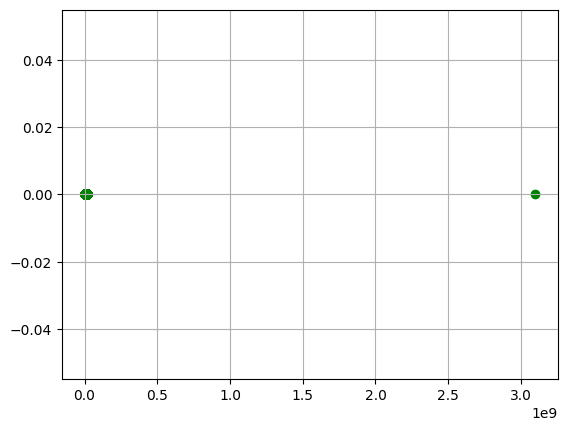

In [8]:
promoters_centres = (promoters.new_start + promoters.new_end) // 2
promoters_centres = [0] + list(promoters_centres.values) + [len(genome) - 1]

plt.scatter(promoters_centres, [0] * len(promoters_centres), c='g')
plt.grid()

In [9]:
np.random.seed(42)

centres = np.random.randint(1e9, 2.5e9, 11000)

non_promoters = pd.DataFrame([
    [
        centre - window_size, centre + window_size,
        genome[centre - window_size:centre + window_size + 1]
    ] for centre in centres
], columns=('start', 'end', 'sequence'))

non_promoters.head()

,start,end,sequence
0,2273642319,2273642519,TTCTCCTGCCTCAGCCTCCCAAGTAGCTGGGACTACAGGCGCCTGC...
1,1787846314,1787846514,CCTCCTGGGTCCAAGCAATTTTCCTGCCTCAGCCTCCTGAGTAGCT...
2,1996406278,1996406478,TAAGGAATCTACAAAATAACTAGTAGAAGTGACAAATGAATTTAGC...
3,2201263587,2201263787,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
4,1423734872,1423735072,TTGATTTTCCTTTGCCCAAACAAGTGGTTCACATATGAAGATGTCT...


In [10]:
# Отбираем только те последовательности, где нет пропусков:
mask = ['N' not in seq for seq in non_promoters.sequence]

non_promoters = non_promoters[mask][:10000].reset_index().drop('index', axis=1)[:promoters.shape[0]]

non_promoters.tail()

,start,end,sequence
9995,1244032893,1244033093,ATATCTACAAACCAAGGAACATCAGGCTGCCCAAACTGCAGGCTGC...
9996,1967397909,1967398109,ATGGGAATTGACTGGAGATGTTATTCTCATTTTACAGATATAAATA...
9997,1779365148,1779365348,TTCGCCTGAGCAGGTGGGGCAGGCTGAAATGCCTGGAGTTATCACA...
9998,2404205521,2404205721,TGCACCACCATAACCAGCTATTTTCTTATTTTTTTCTACAGAGACA...
9999,1458227061,1458227261,AGTCTCACTCTGTTGCCCAGGCTGGAGTGCAGTGGCGCGACCTCGG...


In [11]:
set(promoters.sequence.values) & set(non_promoters.sequence.values)

set()

In [53]:
dataset = pd.concat((
    promoters[['start', 'end', 'sequence']], non_promoters
)).reset_index().drop(columns='index')

dataset['label'] = [0] * promoters.shape[0] + [1] * non_promoters.shape[0]

dataset.to_csv('drive/MyDrive/CompLing/ADL/project/dataset.csv', index=False)

dataset

,start,end,sequence,label
0,9877,10432,TAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAAC...,0
1,9894,10447,CCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCAACCCTAA...,0
2,9898,10346,CCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTA...,0
3,9940,10394,AACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCAACCC...,0
4,9946,10266,TAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAAC...,0
...,...,...,...,...
19995,1244032893,1244033093,ATATCTACAAACCAAGGAACATCAGGCTGCCCAAACTGCAGGCTGC...,1
19996,1967397909,1967398109,ATGGGAATTGACTGGAGATGTTATTCTCATTTTACAGATATAAATA...,1
19997,1779365148,1779365348,TTCGCCTGAGCAGGTGGGGCAGGCTGAAATGCCTGGAGTTATCACA...,1
19998,2404205521,2404205721,TGCACCACCATAACCAGCTATTTTCTTATTTTTTTCTACAGAGACA...,1


## 3. Вспомогательные классы и функции

In [ ]:
class DNADataset(Dataset):
    """Dataset class for DNA sequences"""

    def __init__(self, sequences, labels, max_length=100):
        """
        Args:
            sequences (list): List of DNA sequences as strings
            labels (list): List of corresponding labels
            max_length (int): Maximum sequence length (shorter sequences will be padded)
        """
        self.sequences = sequences
        self.labels = labels
        self.max_length = max_length

        # Кодируем нуклеотиды:
        self.nucleotide_to_index = {'A': 0, 'T': 1, 'C': 2, 'G': 3}

        # Кодируем последовательности:
        self.encoded_sequences = [self._encode_sequence(seq) for seq in sequences]

    def _encode_sequence(self, sequence):
        # Усечение / паддинг до max_length:
        if len(sequence) > self.max_length:
            sequence = sequence[:self.max_length]
        else:
            sequence = sequence + 'N' * (self.max_length - len(sequence))

        # One-hot кодирование: [max_length, 4]
        encoded = torch.zeros(self.max_length, 4)

        for i, nucleotide in enumerate(sequence):
            if nucleotide in self.nucleotide_to_index:
                encoded[i, self.nucleotide_to_index[nucleotide]] = 1.0
            # 'N' и другие символы остаются 0 (неизвестные нуклеотиды)

        return encoded

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        sequence = self.encoded_sequences[idx]
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return sequence, label

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=50, device='cuda'):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(num_epochs):
        # Обучение:
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (data, targets) in enumerate(train_loader):
            data, targets = data.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # Валидация:
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for data, targets in val_loader:
                data, targets = data.to(device), targets.to(device)

                outputs = model(data)
                loss = criterion(outputs, targets)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct / total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}]')
            print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
            print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
            print('-' * 50)

    return train_losses, val_losses, train_accs, val_accs

In [ ]:
def make_experiment(promoters, non_promoters, conv_layers='initial', classifier='initial', lstm_layer='initial', model_type='CNN'):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}')

    sequences = promoters + non_promoters

    labels = [0] * len(promoters) + [1] * len(non_promoters)  # 0: promoter, 1: non-promoter

    X_train, X_test, y_train, y_test = train_test_split(
        sequences, labels, test_size=0.2, random_state=42, stratify=labels
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
    )

    print(f'Training samples: {len(X_train)}')
    print(f'Validation samples: {len(X_val)}')
    print(f'Test samples: {len(X_test)}')

    # Создание датасетов:
    max_length = 100
    train_dataset = DNADataset(X_train, y_train, max_length)
    val_dataset = DNADataset(X_val, y_val, max_length)
    test_dataset = DNADataset(X_test, y_test, max_length)

    # Создание data loaders:
    batch_size = 4
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Создание модели:
    if model_type == 'CNN':
        model = DNA_CNN(
            input_channels=4, num_classes=2, conv_layers=conv_layers, classifier=classifier
        )
    elif model_type == 'CNN_RNN':
        model = DNA_CNN_RNN(
            input_channels=4, num_classes=2, conv_layers=conv_layers,
            lstm_layer=lstm_layer, classifier=classifier
        )

    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    # Обучение:
    print('Starting training...')
    train_losses, val_losses, train_accs, val_accs = train_model(
        model, train_loader, val_loader, criterion, optimizer, num_epochs=30, device=device
    )

    # Оценка:
    model.eval()
    test_correct = 0
    test_total = 0
    all_probs = []
    all_preds = []
    all_targets = []
    threshold = 0.7

    with torch.no_grad():
        for data, targets in test_loader:
            data, targets = data.to(device), targets.to(device)

            outputs = model(data)
            _, predicted = outputs.max(1)

            probs = nn.functional.softmax(outputs, dim=1)[:, 1]
            preds = (probs >= threshold).long()

            test_total += targets.size(0)
            test_correct += predicted.eq(targets).sum().item()

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    test_acc = 100. * test_correct / test_total
    print(f'Test Accuracy: {test_acc:.2f}%')

    # Качество и графики
    print('\nClassification Report:')
    print(classification_report(all_targets, all_preds))

    plt.figure(figsize=(12, 4))

    fig, axes = plt.subplots(2, 2, figsize=(16, 9))

    axes[0, 0].plot(train_losses, label='Train Loss')
    axes[0, 0].plot(val_losses, label='Validation Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].set_title('Training and Validation Loss')

    axes[0, 1].plot(train_accs, label='Train Accuracy')
    axes[0, 1].plot(val_accs, label='Validation Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].legend()
    axes[0, 1].set_title('Training and Validation Accuracy')


    # ROC-curve
    fpr, tpr, thresholds = roc_curve(all_targets, all_probs)
    roc_auc = auc(fpr, tpr)

    axes[1, 0].plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
    axes[1, 0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
    axes[1, 0].fill_between(fpr, tpr, alpha=0.2, color='darkblue')
    axes[1, 0].set_xlabel('False Positive Rate')
    axes[1, 0].set_ylabel('True Positive Rate')
    axes[1, 0].set_title('ROC Curve')
    axes[1, 0].legend(loc='lower right')
    axes[1, 0].grid(alpha=0.3)

    # PR-curve
    precision, recall, thresholds = precision_recall_curve(all_targets, all_probs)
    ap = average_precision_score(all_targets, all_preds)

    axes[1, 1].plot(recall, precision, color='darkred', lw=2, label=f'PR (AP = {ap:.3f})')
    no_skill = sum(all_targets) / len(all_targets)
    axes[1, 1].axhline(y=no_skill, color='k', linestyle='--', alpha=0.5, label='No Skill')
    axes[1, 1].fill_between(recall, precision, alpha=0.2, color='darkred')
    axes[1, 1].set_xlabel('Recall')
    axes[1, 1].set_ylabel('Precision')
    axes[1, 1].set_title('Precision-Recall Curve')
    axes[1, 1].legend(loc='lower left')
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 4. CNN

### Модель

In [ ]:
class DNA_CNN(nn.Module):
    """CNN model for DNA sequence classification"""
    def __init__(self, input_channels=4, num_classes=2, conv_layers='initial', classifier='inintial'):
        super(DNA_CNN, self).__init__()

        if conv_layers == 'initial':
            self.conv_layers = nn.Sequential(
                # First convolutional block
                nn.Conv1d(input_channels, 64, kernel_size=10, padding=5),
                nn.ReLU(),
                nn.BatchNorm1d(64),
                nn.MaxPool1d(2),
                nn.Dropout(0.3),

                # Second convolutional block
                nn.Conv1d(64, 128, kernel_size=8, padding=4),
                nn.ReLU(),
                nn.BatchNorm1d(128),
                nn.MaxPool1d(2),
                nn.Dropout(0.3),

                # Third convolutional block
                nn.Conv1d(128, 256, kernel_size=6, padding=3),
                nn.ReLU(),
                nn.BatchNorm1d(256),
                nn.MaxPool1d(2),
                nn.Dropout(0.3),

                # Fourth convolutional block
                nn.Conv1d(256, 512, kernel_size=4, padding=2),
                nn.ReLU(),
                nn.BatchNorm1d(512),
                nn.MaxPool1d(2),
                nn.Dropout(0.3)
            )
        else:
            self.conv_layers = conv_layers

        if classifier == 'initial':
            self.classifier = nn.Sequential(
                nn.AdaptiveAvgPool1d(1),
                nn.Flatten(),
                nn.Linear(512, 256),
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(128, num_classes)
            )
        else:
            self.classifier = classifier

    def forward(self, x):
        x = x.permute(0, 2, 1)

        x = self.conv_layers(x)
        x = self.classifier(x)
        return x

### 3-layer CNN

Using device: cuda
Training samples: 12800
Validation samples: 3200
Test samples: 4000
Starting training...
Epoch [10/30]
Train Loss: 0.3437, Train Acc: 85.90%
Val Loss: 0.3056, Val Acc: 88.41%
--------------------------------------------------
Epoch [20/30]
Train Loss: 0.2983, Train Acc: 88.14%
Val Loss: 0.3433, Val Acc: 89.19%
--------------------------------------------------
Epoch [30/30]
Train Loss: 0.2636, Train Acc: 89.52%
Val Loss: 0.2800, Val Acc: 90.09%
--------------------------------------------------
Test Accuracy: 89.58%

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      2000
           1       0.88      0.92      0.90      2000

    accuracy                           0.90      4000
   macro avg       0.90      0.90      0.90      4000
weighted avg       0.90      0.90      0.90      4000



<Figure size 1200x400 with 0 Axes>

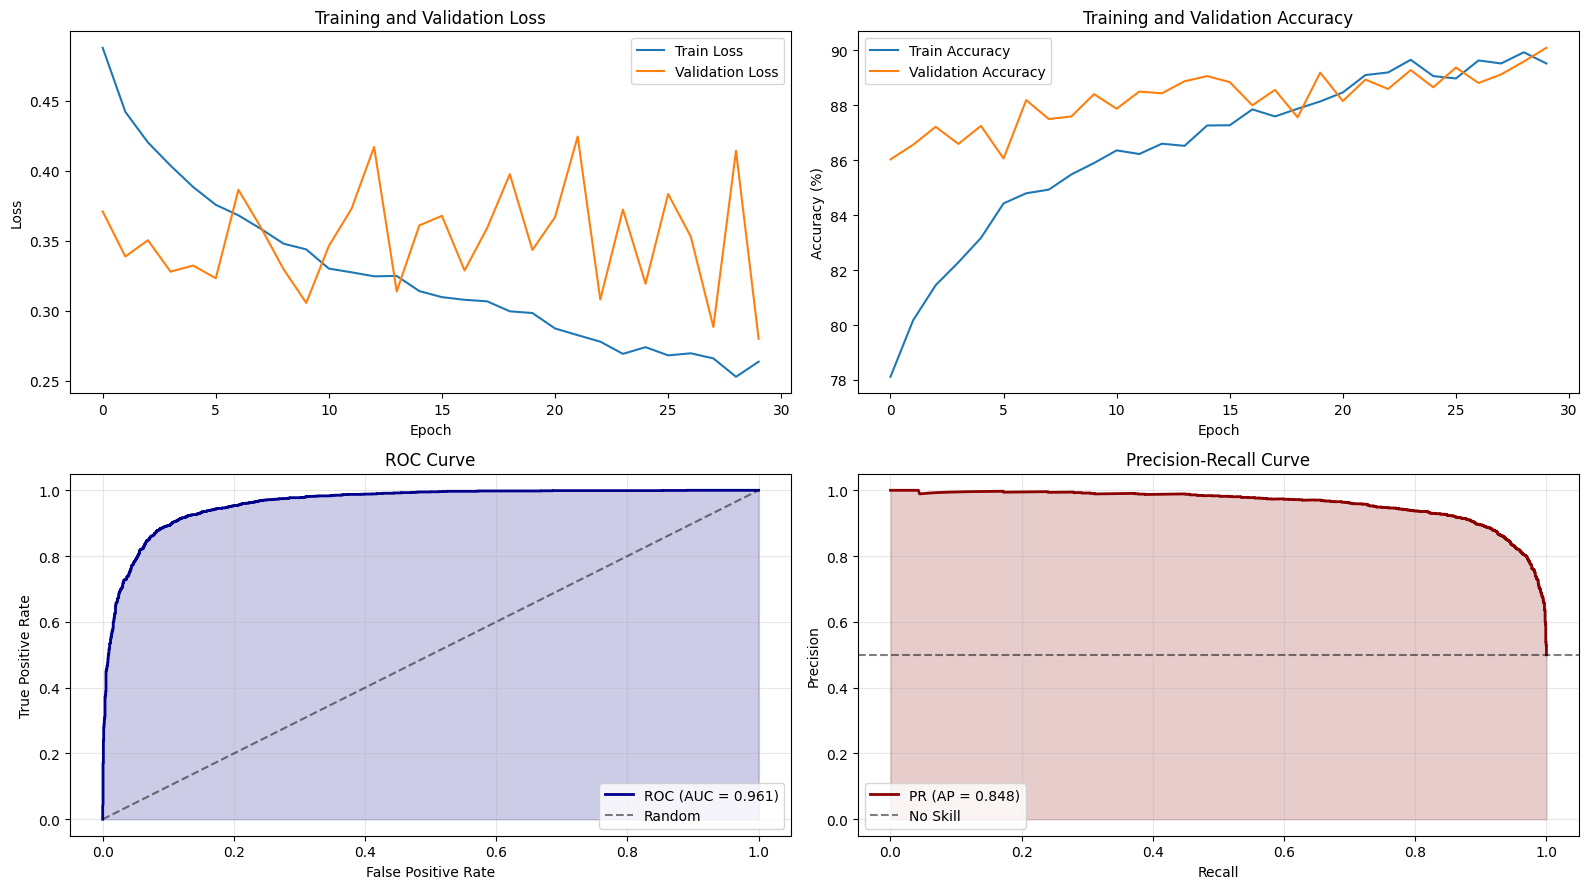

In [ ]:
### 1. neurons_nums=initial, kernels_nums_dependence=reverse ###

conv_layers = nn.Sequential(
    # First convolutional block
    nn.Conv1d(4, 64, kernel_size=10, padding=5),
    nn.ReLU(),
    nn.BatchNorm1d(64),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Second convolutional block
    nn.Conv1d(64, 128, kernel_size=8, padding=4),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Third convolutional block
    nn.Conv1d(128, 512, kernel_size=6, padding=3),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.MaxPool1d(2),
    nn.Dropout(0.3)
)

make_experiment(list(promoters.sequence.values), list(non_promoters.sequence.values), conv_layers)

Using device: cuda
Training samples: 12800
Validation samples: 3200
Test samples: 4000
Starting training...
Epoch [10/30]
Train Loss: 0.3329, Train Acc: 86.27%
Val Loss: 0.3473, Val Acc: 85.66%
--------------------------------------------------
Epoch [20/30]
Train Loss: 0.2969, Train Acc: 88.29%
Val Loss: 0.3215, Val Acc: 87.88%
--------------------------------------------------
Epoch [30/30]
Train Loss: 0.2608, Train Acc: 89.73%
Val Loss: 0.3694, Val Acc: 87.75%
--------------------------------------------------
Test Accuracy: 88.47%

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89      2000
           1       0.92      0.84      0.88      2000

    accuracy                           0.88      4000
   macro avg       0.89      0.88      0.88      4000
weighted avg       0.89      0.88      0.88      4000



<Figure size 1200x400 with 0 Axes>

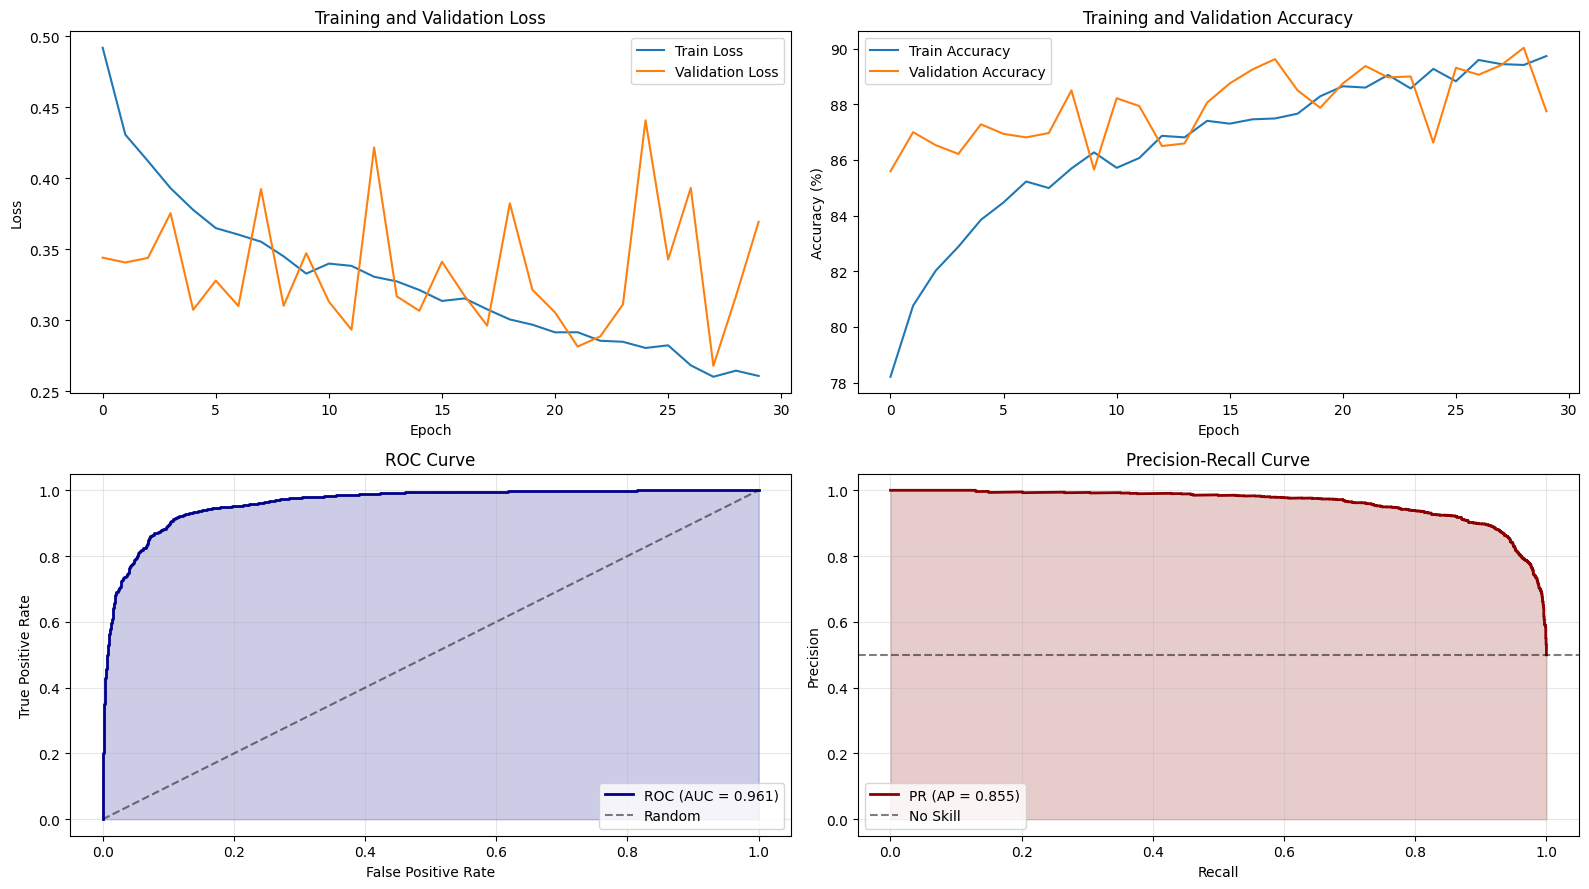

In [ ]:
### 2. neurons_nums=initial, kernels_nums_dependence=straight ###

conv_layers = nn.Sequential(
    # First convolutional block
    nn.Conv1d(4, 64, kernel_size=6, padding=3),
    nn.ReLU(),
    nn.BatchNorm1d(64),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Second convolutional block
    nn.Conv1d(64, 128, kernel_size=8, padding=4),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Third convolutional block
    nn.Conv1d(128, 512, kernel_size=10, padding=5),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.MaxPool1d(2),
    nn.Dropout(0.3)
)

make_experiment(list(promoters.sequence.values), list(non_promoters.sequence.values), conv_layers)

Using device: cuda
Training samples: 12800
Validation samples: 3200
Test samples: 4000
Starting training...
Epoch [10/30]
Train Loss: 0.3717, Train Acc: 84.53%
Val Loss: 0.4275, Val Acc: 87.50%
--------------------------------------------------
Epoch [20/30]
Train Loss: 0.2922, Train Acc: 88.80%
Val Loss: 0.4125, Val Acc: 88.91%
--------------------------------------------------
Epoch [30/30]
Train Loss: 0.2534, Train Acc: 90.31%
Val Loss: 0.4757, Val Acc: 89.16%
--------------------------------------------------
Test Accuracy: 90.25%

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      2000
           1       0.91      0.89      0.90      2000

    accuracy                           0.90      4000
   macro avg       0.90      0.90      0.90      4000
weighted avg       0.90      0.90      0.90      4000



<Figure size 1200x400 with 0 Axes>

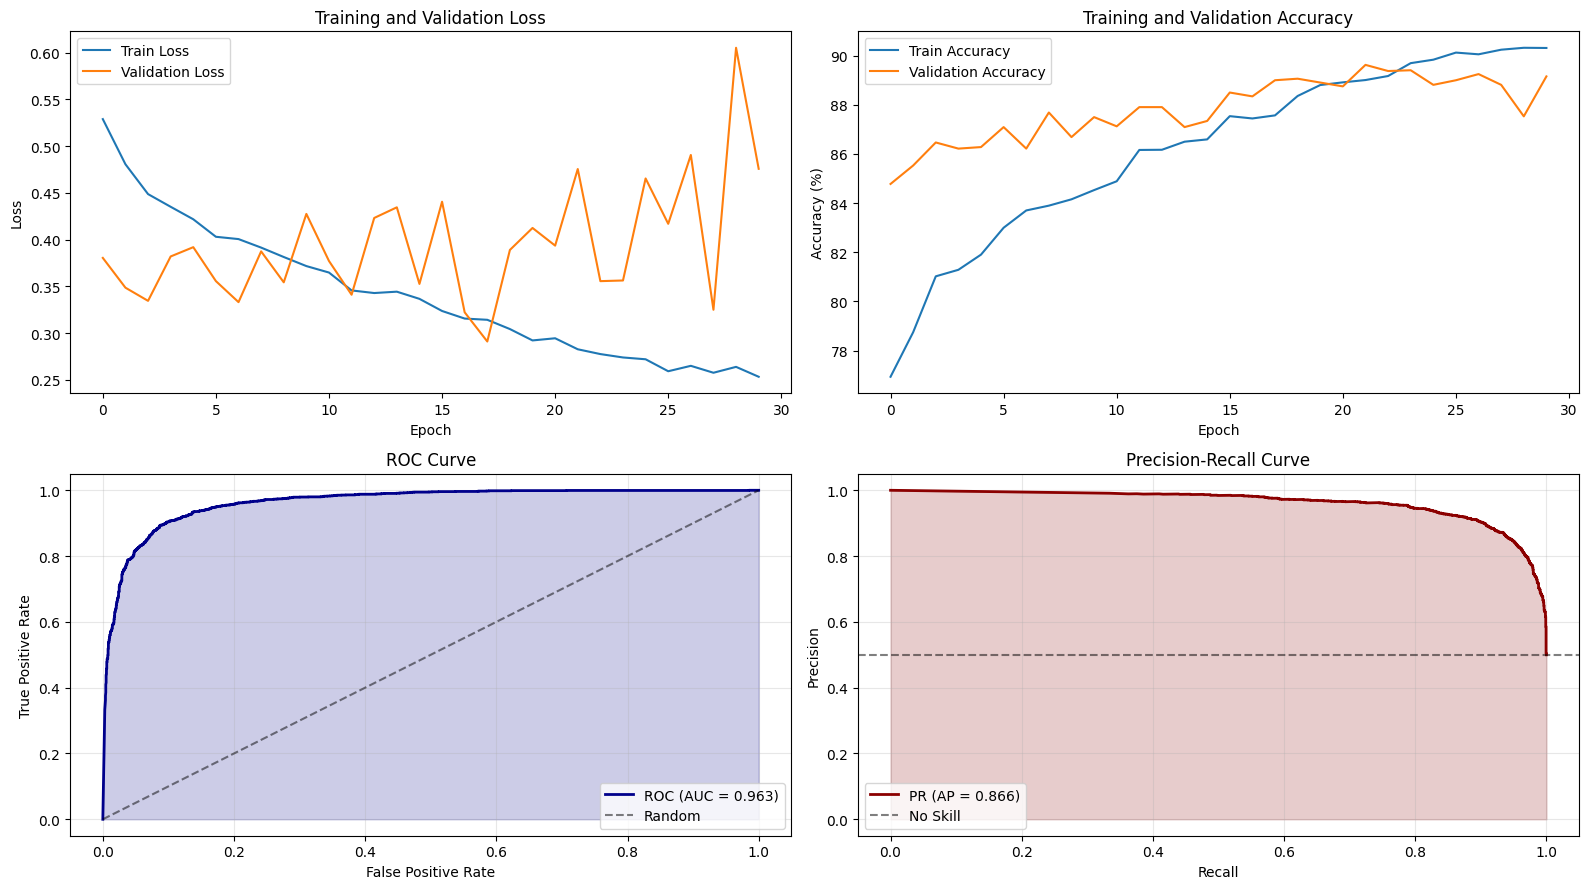

In [ ]:
### 3. neurons_nums=increased, kernels_nums_dependence=reverse ###

conv_layers = nn.Sequential(
    # First convolutional block
    nn.Conv1d(4, 64, kernel_size=12, padding=6),
    nn.ReLU(),
    nn.BatchNorm1d(64),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Second convolutional block
    nn.Conv1d(64, 256, kernel_size=10, padding=5),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Third convolutional block
    nn.Conv1d(256, 1024, kernel_size=8, padding=4),
    nn.ReLU(),
    nn.BatchNorm1d(1024),
    nn.MaxPool1d(2),
    nn.Dropout(0.3)
)

classifier = nn.Sequential(
    nn.AdaptiveAvgPool1d(1),
    nn.Flatten(),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(64, 4)
)

make_experiment(list(promoters.sequence.values), list(non_promoters.sequence.values), conv_layers, classifier)

Using device: cuda
Training samples: 12800
Validation samples: 3200
Test samples: 4000
Starting training...
Epoch [10/30]
Train Loss: 0.3774, Train Acc: 84.63%
Val Loss: 9.5204, Val Acc: 86.50%
--------------------------------------------------
Epoch [20/30]
Train Loss: 0.3222, Train Acc: 87.22%
Val Loss: 0.3358, Val Acc: 87.97%
--------------------------------------------------
Epoch [30/30]
Train Loss: 0.2822, Train Acc: 88.88%
Val Loss: 0.5073, Val Acc: 87.22%
--------------------------------------------------
Test Accuracy: 88.90%

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.94      0.89      2000
           1       0.93      0.84      0.88      2000

    accuracy                           0.89      4000
   macro avg       0.89      0.89      0.89      4000
weighted avg       0.89      0.89      0.89      4000



<Figure size 1200x400 with 0 Axes>

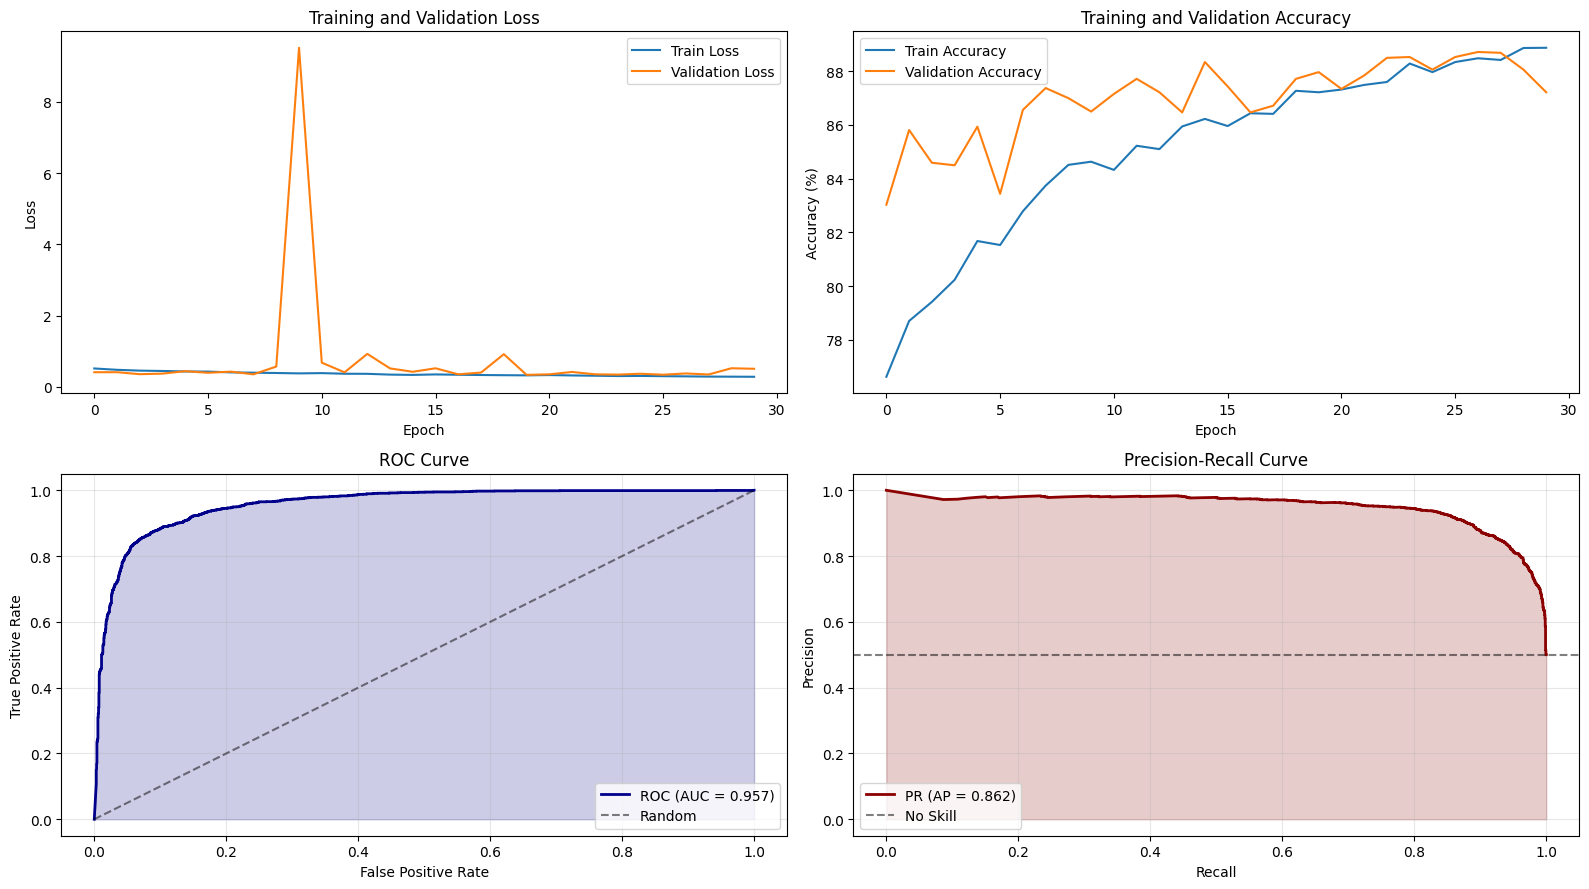

In [ ]:
### 4. neurons_nums=increased, kernels_nums_dependence=straight ###

conv_layers = nn.Sequential(
    # First convolutional block
    nn.Conv1d(4, 64, kernel_size=4, padding=2),
    nn.ReLU(),
    nn.BatchNorm1d(64),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Second convolutional block
    nn.Conv1d(64, 256, kernel_size=8, padding=4),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Third convolutional block
    nn.Conv1d(256, 1024, kernel_size=12, padding=6),
    nn.ReLU(),
    nn.BatchNorm1d(1024),
    nn.MaxPool1d(2),
    nn.Dropout(0.3)
)

classifier = nn.Sequential(
    nn.AdaptiveAvgPool1d(1),
    nn.Flatten(),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(64, 4)
)

make_experiment(list(promoters.sequence.values), list(non_promoters.sequence.values), conv_layers, classifier)

### 4-layer CNN

Using device: cuda
Training samples: 12800
Validation samples: 3200
Test samples: 4000
Starting training...
Epoch [10/30]
Train Loss: 0.3496, Train Acc: 85.35%
Val Loss: 0.3343, Val Acc: 88.00%
--------------------------------------------------
Epoch [20/30]
Train Loss: 0.2935, Train Acc: 88.19%
Val Loss: 0.4123, Val Acc: 88.25%
--------------------------------------------------
Epoch [30/30]
Train Loss: 0.2499, Train Acc: 90.17%
Val Loss: 0.3902, Val Acc: 89.06%
--------------------------------------------------
Test Accuracy: 89.83%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      2000
           1       0.92      0.87      0.90      2000

    accuracy                           0.90      4000
   macro avg       0.90      0.90      0.90      4000
weighted avg       0.90      0.90      0.90      4000



<Figure size 1200x400 with 0 Axes>

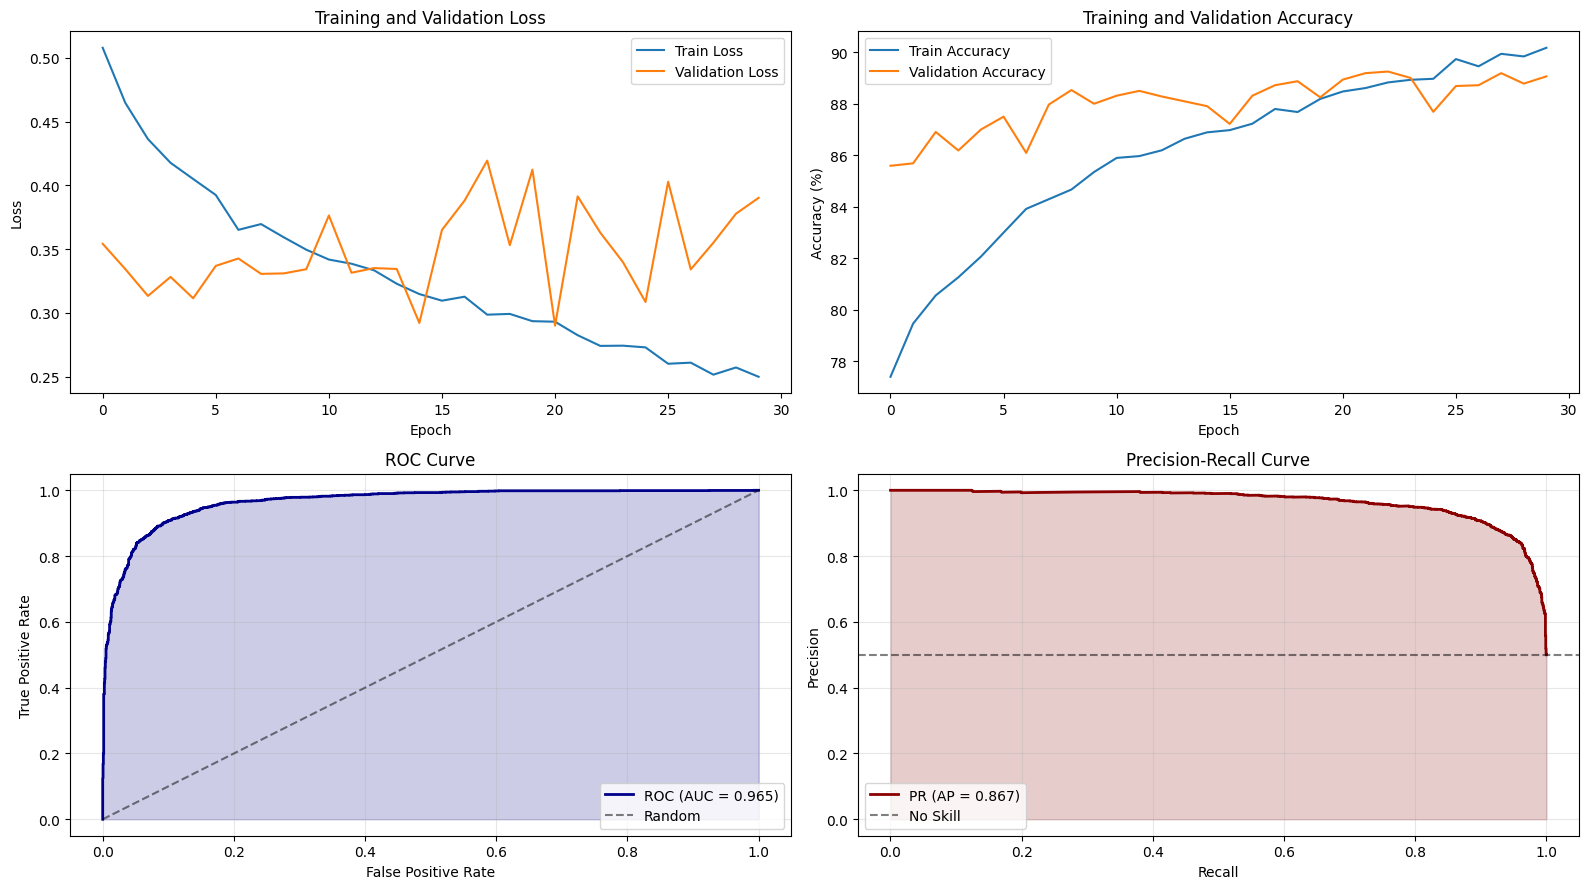

In [ ]:
### 1. neurons_nums=initial, kernels_nums_dependence=reverse ###

make_experiment(list(promoters.sequence.values), list(non_promoters.sequence.values))

Using device: cuda
Training samples: 12800
Validation samples: 3200
Test samples: 4000
Starting training...
Epoch [10/30]
Train Loss: 0.3685, Train Acc: 84.09%
Val Loss: 0.4192, Val Acc: 85.12%
--------------------------------------------------
Epoch [20/30]
Train Loss: 0.3108, Train Acc: 87.16%
Val Loss: 0.2825, Val Acc: 88.75%
--------------------------------------------------
Epoch [30/30]
Train Loss: 0.2632, Train Acc: 89.75%
Val Loss: 0.3591, Val Acc: 85.97%
--------------------------------------------------
Test Accuracy: 86.75%

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.95      0.88      2000
           1       0.95      0.78      0.85      2000

    accuracy                           0.87      4000
   macro avg       0.88      0.87      0.87      4000
weighted avg       0.88      0.87      0.87      4000



<Figure size 1200x400 with 0 Axes>

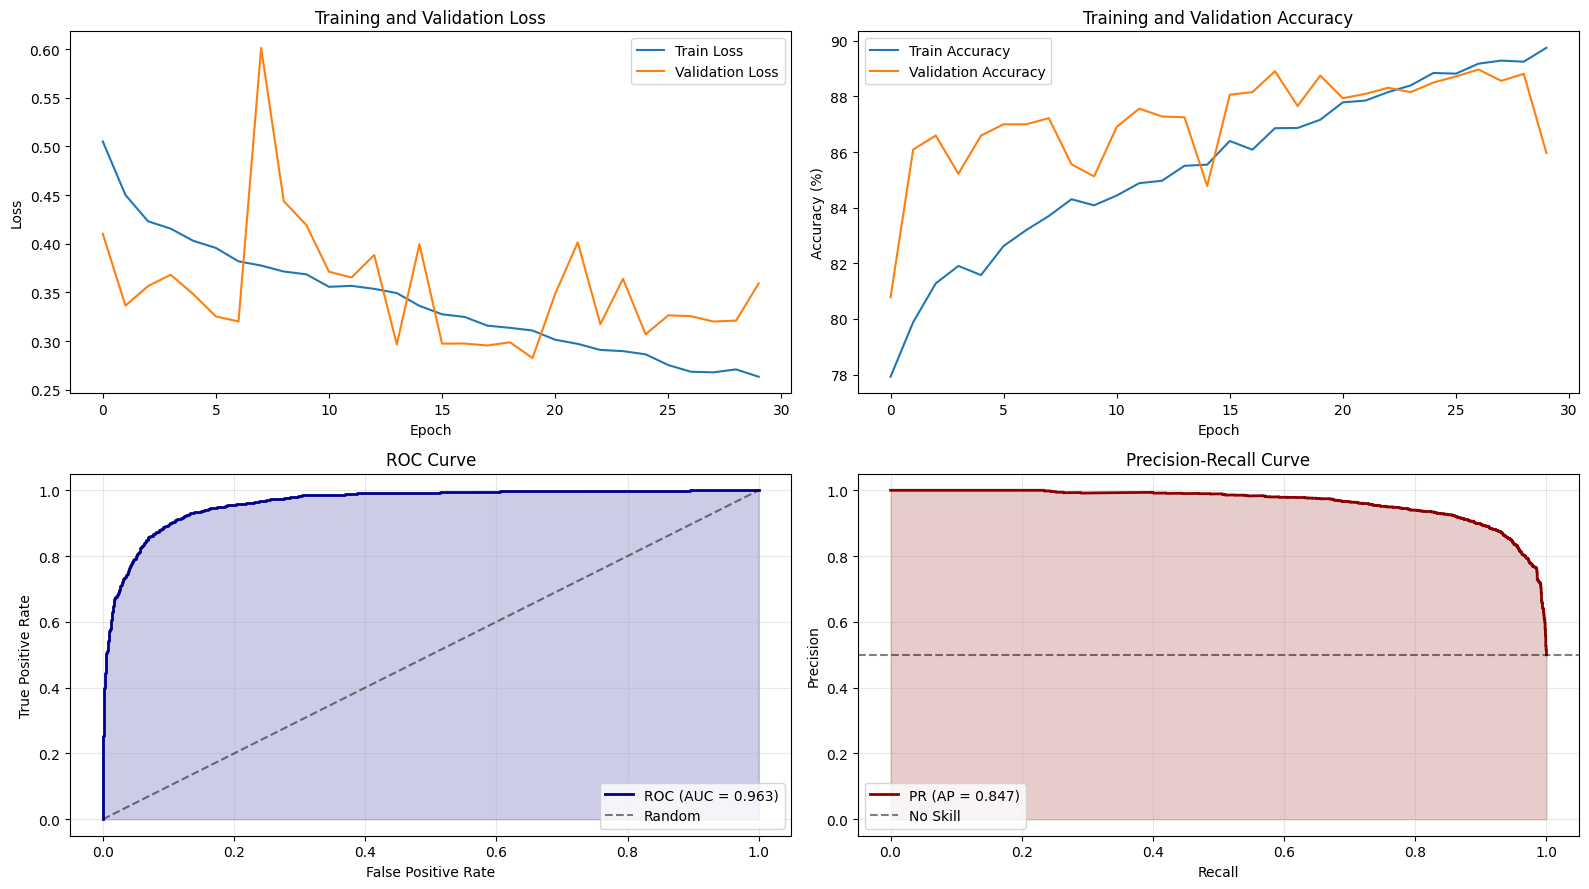

In [ ]:
### 2. neurons_nums=initial, kernels_nums_dependence=straight ###

conv_layers = nn.Sequential(
    # First convolutional block
    nn.Conv1d(4, 64, kernel_size=4, padding=2),
    nn.ReLU(),
    nn.BatchNorm1d(64),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Second convolutional block
    nn.Conv1d(64, 128, kernel_size=6, padding=3),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Third convolutional block
    nn.Conv1d(128, 256, kernel_size=8, padding=4),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Fourth convolutional block
    nn.Conv1d(256, 512, kernel_size=10, padding=5),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.MaxPool1d(2),
    nn.Dropout(0.3)
)

make_experiment(list(promoters.sequence.values), list(non_promoters.sequence.values), conv_layers)

Using device: cuda
Training samples: 12800
Validation samples: 3200
Test samples: 4000
Starting training...
Epoch [10/30]
Train Loss: 0.4089, Train Acc: 82.06%
Val Loss: 0.4137, Val Acc: 86.41%
--------------------------------------------------
Epoch [20/30]
Train Loss: 0.3635, Train Acc: 85.45%
Val Loss: 0.4524, Val Acc: 87.00%
--------------------------------------------------
Epoch [30/30]
Train Loss: 0.3362, Train Acc: 86.49%
Val Loss: 0.3658, Val Acc: 87.88%
--------------------------------------------------
Test Accuracy: 88.58%

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.86      0.88      2000
           1       0.86      0.92      0.89      2000

    accuracy                           0.89      4000
   macro avg       0.89      0.89      0.89      4000
weighted avg       0.89      0.89      0.89      4000



<Figure size 1200x400 with 0 Axes>

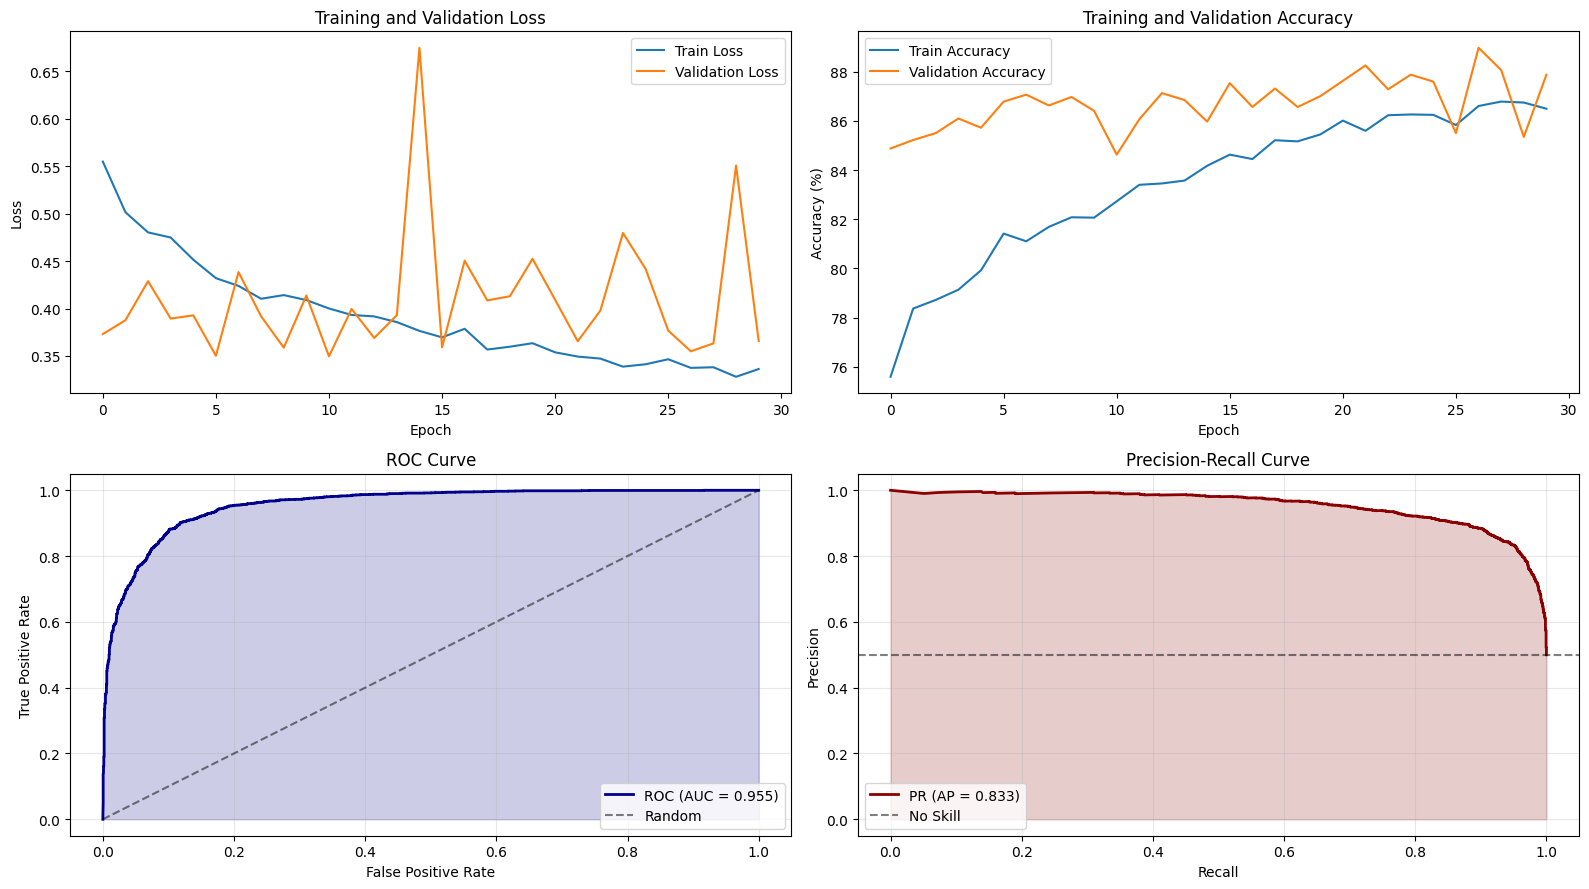

In [ ]:
### 3. neurons_nums=increased, kernels_nums_dependence=reverse ###

conv_layers = nn.Sequential(
    # First convolutional block
    nn.Conv1d(4, 32, kernel_size=10, padding=5),
    nn.ReLU(),
    nn.BatchNorm1d(32),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Second convolutional block
    nn.Conv1d(32, 128, kernel_size=8, padding=4),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Third convolutional block
    nn.Conv1d(128, 512, kernel_size=6, padding=3),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Fourth convolutional block
    nn.Conv1d(512, 1024, kernel_size=4, padding=2),
    nn.ReLU(),
    nn.BatchNorm1d(1024),
    nn.MaxPool1d(2),
    nn.Dropout(0.3)
)

classifier = nn.Sequential(
    nn.AdaptiveAvgPool1d(1),
    nn.Flatten(),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(64, 4)
)

make_experiment(list(promoters.sequence.values), list(non_promoters.sequence.values), conv_layers, classifier)

Using device: cuda
Training samples: 12800
Validation samples: 3200
Test samples: 4000
Starting training...
Epoch [10/30]
Train Loss: 0.4233, Train Acc: 81.51%
Val Loss: 0.5363, Val Acc: 85.00%
--------------------------------------------------
Epoch [20/30]
Train Loss: 0.3780, Train Acc: 83.84%
Val Loss: 0.3317, Val Acc: 86.75%
--------------------------------------------------
Epoch [30/30]
Train Loss: 0.3518, Train Acc: 85.30%
Val Loss: 0.3285, Val Acc: 87.09%
--------------------------------------------------
Test Accuracy: 87.30%

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      2000
           1       0.90      0.84      0.87      2000

    accuracy                           0.87      4000
   macro avg       0.87      0.87      0.87      4000
weighted avg       0.87      0.87      0.87      4000



<Figure size 1200x400 with 0 Axes>

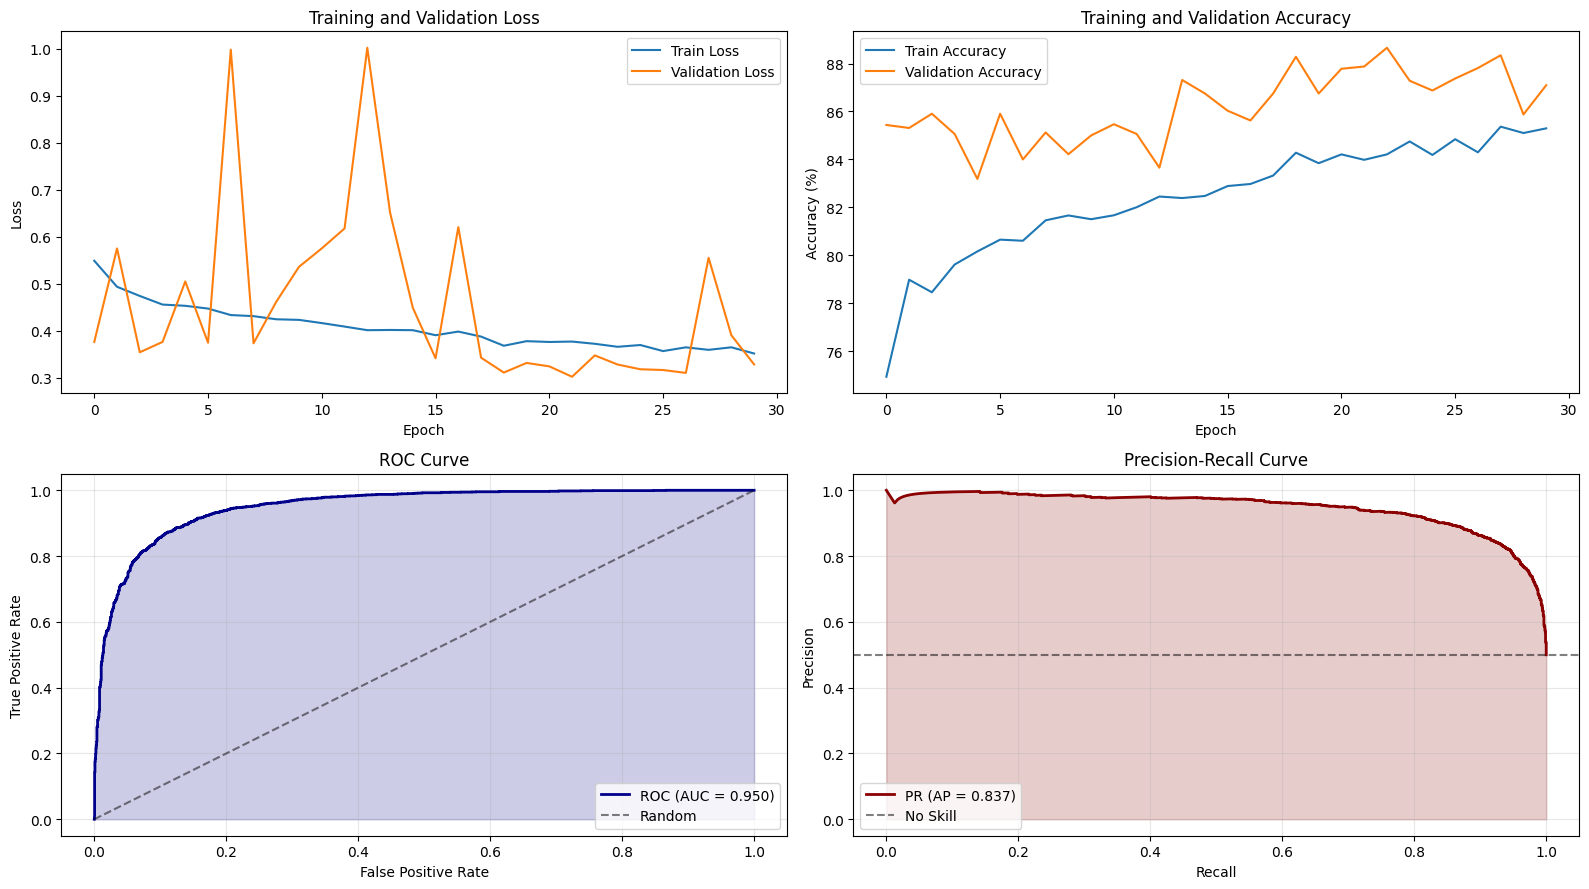

In [ ]:
### 4. neurons_nums=increased, kernels_nums_dependence=straight ###

conv_layers = nn.Sequential(
    # First convolutional block
    nn.Conv1d(4, 32, kernel_size=4, padding=2),
    nn.ReLU(),
    nn.BatchNorm1d(32),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Second convolutional block
    nn.Conv1d(32, 128, kernel_size=6, padding=3),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Third convolutional block
    nn.Conv1d(128, 512, kernel_size=8, padding=4),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Fourth convolutional block
    nn.Conv1d(512, 1024, kernel_size=10, padding=5),
    nn.ReLU(),
    nn.BatchNorm1d(1024),
    nn.MaxPool1d(2),
    nn.Dropout(0.3)
)

classifier = nn.Sequential(
    nn.AdaptiveAvgPool1d(1),
    nn.Flatten(),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(64, 4)
)

make_experiment(list(promoters.sequence.values), list(non_promoters.sequence.values), conv_layers, classifier)

## 5. CNN + RNN

### Модель

In [ ]:
class DNA_CNN_RNN(nn.Module):
    """CNN and RNN model for DNA sequence classification"""
    def __init__(self, input_channels=4, num_classes=2, conv_layers='initial', lstm_layer='initial', classifier='inintial'):
        super(DNA_CNN_RNN, self).__init__()

        if conv_layers == 'initial':
            self.conv_layers = nn.Sequential(
                # First convolutional block
                nn.Conv1d(input_channels, 64, kernel_size=10, padding=5),
                nn.ReLU(),
                nn.BatchNorm1d(64),
                nn.MaxPool1d(2),
                nn.Dropout(0.3),

                # Second convolutional block
                nn.Conv1d(64, 128, kernel_size=8, padding=4),
                nn.ReLU(),
                nn.BatchNorm1d(128),
                nn.MaxPool1d(2),
                nn.Dropout(0.3),

                # Third convolutional block
                nn.Conv1d(128, 256, kernel_size=6, padding=3),
                nn.ReLU(),
                nn.BatchNorm1d(256),
                nn.MaxPool1d(2),
                nn.Dropout(0.3),

                # Fourth convolutional block
                nn.Conv1d(256, 512, kernel_size=4, padding=2),
                nn.ReLU(),
                nn.BatchNorm1d(512),
                nn.MaxPool1d(2),
                nn.Dropout(0.3)
            )
        else:
            self.conv_layers = conv_layers

        if lstm_layer == 'initial':
            self.lstm_layer = nn.LSTM(
                input_size=512,
                hidden_size=128,
                num_layers=1,
                batch_first=True,
                bidirectional=True
            )
        else:
            self.lstm_layer = lstm_layer

        if classifier == 'initial':
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(64, num_classes)
            )
        else:
            self.classifier = classifier

    def forward(self, x):
        x = x.permute(0, 2, 1)

        x = self.conv_layers(x)
        x = x.permute(0, 2, 1)

        output, (hn, cn) = self.lstm_layer(x)

        if self.lstm_layer.bidirectional:
            x = torch.cat((hn[-2], hn[-1]), dim=1)
        else:
            x = hn[-1]

        x = nn.Dropout(0.3)(x)
        x = self.classifier(x)
        return x

### 3-layer CNN

Using device: cuda
Training samples: 12800
Validation samples: 3200
Test samples: 4000
Starting training...
Epoch [10/30]
Train Loss: 0.3498, Train Acc: 85.48%
Val Loss: 0.3155, Val Acc: 87.06%
--------------------------------------------------
Epoch [20/30]
Train Loss: 0.3175, Train Acc: 87.35%
Val Loss: 0.3375, Val Acc: 87.81%
--------------------------------------------------
Epoch [30/30]
Train Loss: 0.2947, Train Acc: 88.29%
Val Loss: 0.3224, Val Acc: 88.06%
--------------------------------------------------
Test Accuracy: 88.22%

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.91      0.89      2000
           1       0.91      0.85      0.88      2000

    accuracy                           0.88      4000
   macro avg       0.88      0.88      0.88      4000
weighted avg       0.88      0.88      0.88      4000



<Figure size 1200x400 with 0 Axes>

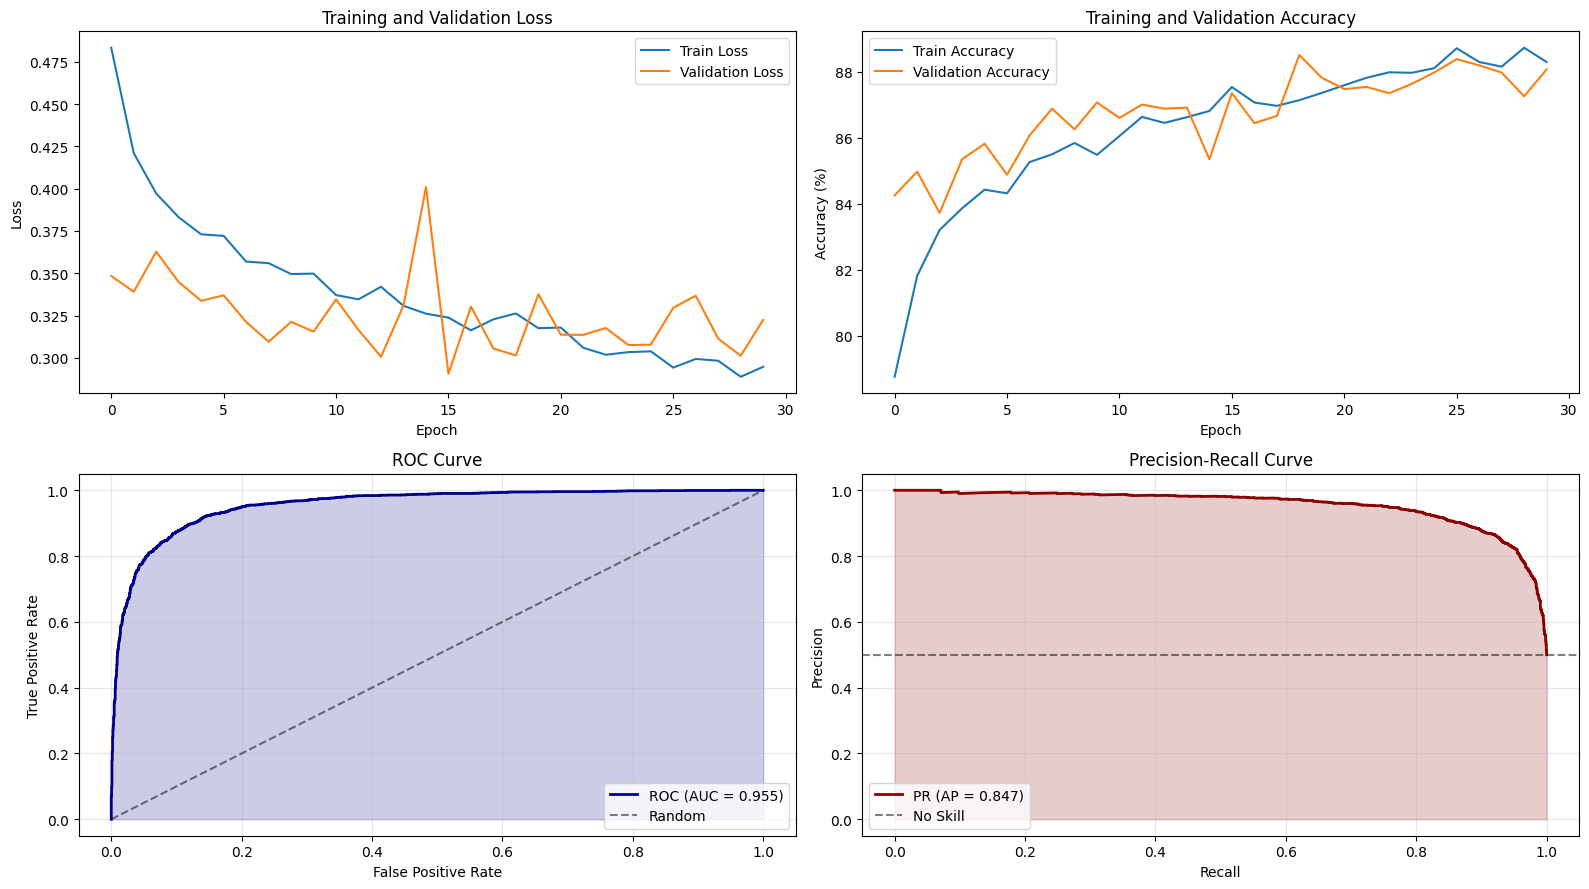

In [ ]:
### 1. neurons_nums=initial, hidden_size=initial ###

conv_layers = nn.Sequential(
    # First convolutional block
    nn.Conv1d(4, 64, kernel_size=10, padding=5),
    nn.ReLU(),
    nn.BatchNorm1d(64),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Second convolutional block
    nn.Conv1d(64, 128, kernel_size=8, padding=4),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Third convolutional block
    nn.Conv1d(128, 512, kernel_size=6, padding=3),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.MaxPool1d(2),
    nn.Dropout(0.3)
)

make_experiment(list(promoters.sequence.values), list(non_promoters.sequence.values), conv_layers, model_type='CNN_RNN')

Using device: cuda
Training samples: 12800
Validation samples: 3200
Test samples: 4000
Starting training...
Epoch [10/30]
Train Loss: 0.3746, Train Acc: 84.91%
Val Loss: 0.3073, Val Acc: 87.06%
--------------------------------------------------
Epoch [20/30]
Train Loss: 0.3531, Train Acc: 86.34%
Val Loss: 0.3298, Val Acc: 87.09%
--------------------------------------------------
Epoch [30/30]
Train Loss: 0.3568, Train Acc: 86.05%
Val Loss: 0.3255, Val Acc: 86.59%
--------------------------------------------------
Test Accuracy: 88.20%

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      2000
           1       0.91      0.84      0.88      2000

    accuracy                           0.88      4000
   macro avg       0.88      0.88      0.88      4000
weighted avg       0.88      0.88      0.88      4000



<Figure size 1200x400 with 0 Axes>

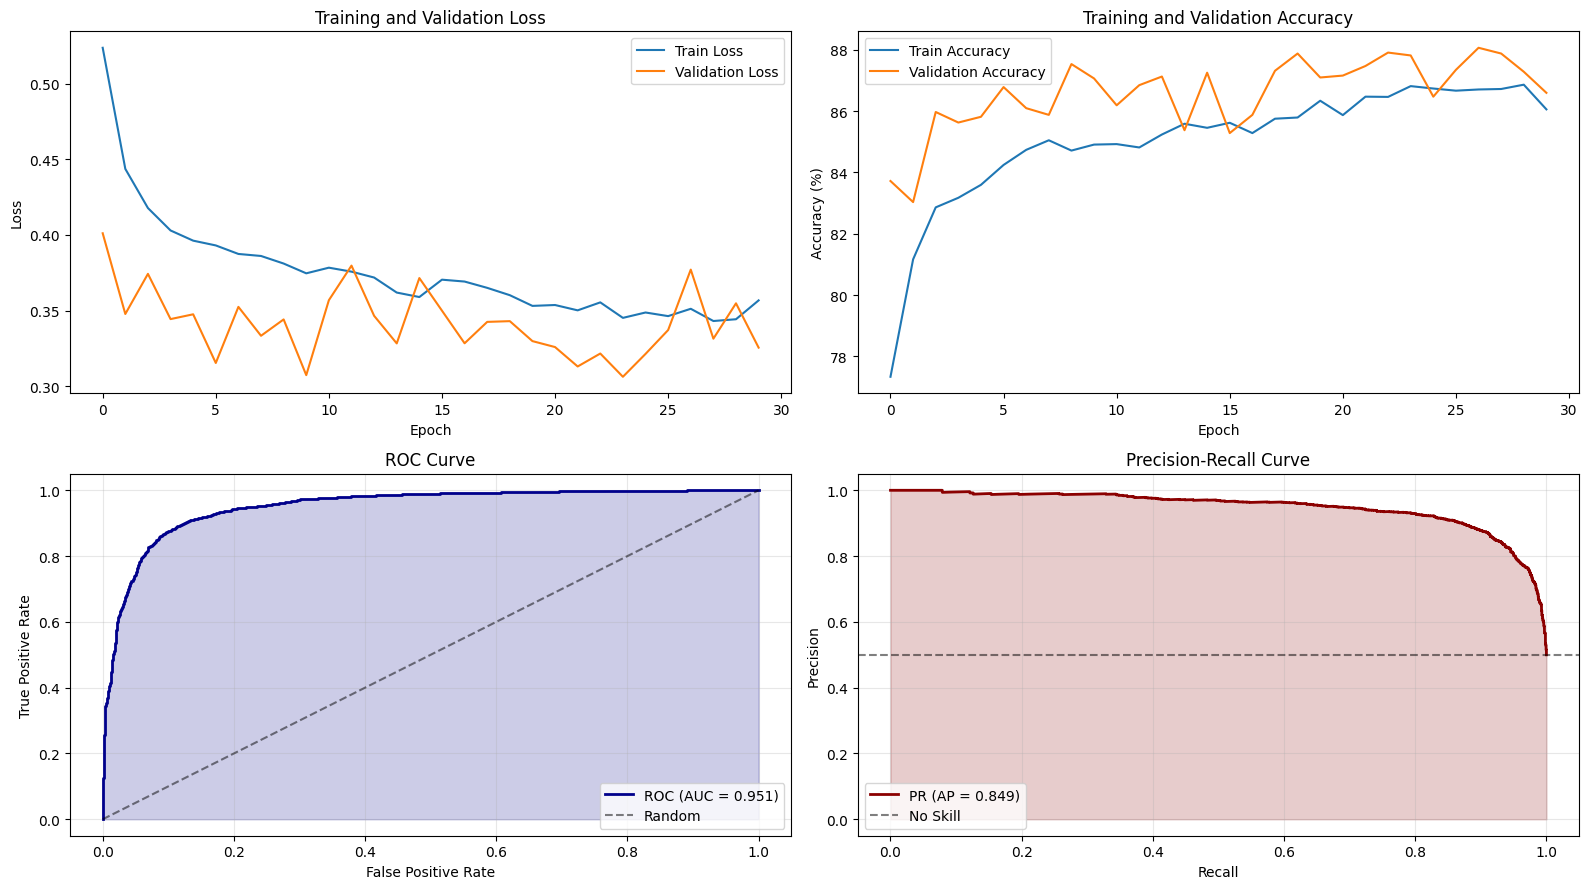

In [ ]:
### 2. neurons_nums=initial, hidden_size=increased ###

conv_layers = nn.Sequential(
    # First convolutional block
    nn.Conv1d(4, 64, kernel_size=10, padding=5),
    nn.ReLU(),
    nn.BatchNorm1d(64),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Second convolutional block
    nn.Conv1d(64, 128, kernel_size=8, padding=4),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Third convolutional block
    nn.Conv1d(128, 512, kernel_size=6, padding=3),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.MaxPool1d(2),
    nn.Dropout(0.3)
)

lstm_layer = nn.LSTM(
    input_size=512,
    hidden_size=256,
    num_layers=1,
    batch_first=True,
    bidirectional=True
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(64, 4)
)

make_experiment(
    list(promoters.sequence.values), list(non_promoters.sequence.values),
    conv_layers, classifier, lstm_layer, model_type='CNN_RNN'
)

Using device: cuda
Training samples: 12800
Validation samples: 3200
Test samples: 4000
Starting training...
Epoch [10/30]
Train Loss: 0.3711, Train Acc: 84.77%
Val Loss: 0.3133, Val Acc: 85.47%
--------------------------------------------------
Epoch [20/30]
Train Loss: 0.3193, Train Acc: 87.05%
Val Loss: 0.3145, Val Acc: 87.09%
--------------------------------------------------
Epoch [30/30]
Train Loss: 0.2997, Train Acc: 88.62%
Val Loss: 0.3463, Val Acc: 87.66%
--------------------------------------------------
Test Accuracy: 89.05%

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.93      0.89      2000
           1       0.92      0.85      0.89      2000

    accuracy                           0.89      4000
   macro avg       0.89      0.89      0.89      4000
weighted avg       0.89      0.89      0.89      4000



<Figure size 1200x400 with 0 Axes>

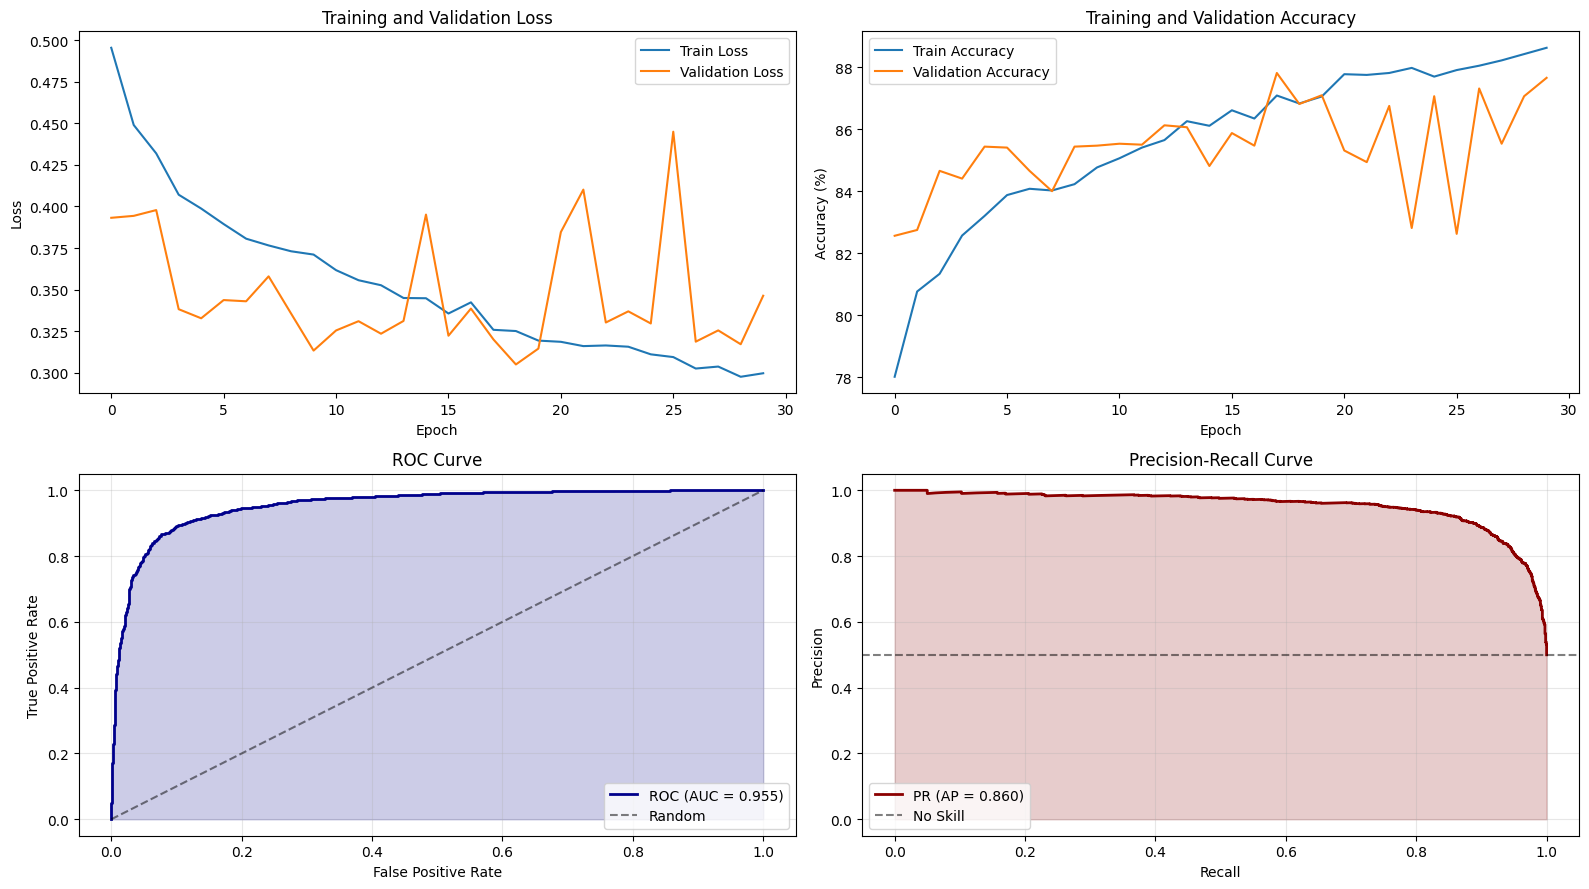

In [ ]:
### 3. neurons_nums=increased, hidden_size=initial ###

conv_layers = nn.Sequential(
    # First convolutional block
    nn.Conv1d(4, 64, kernel_size=12, padding=6),
    nn.ReLU(),
    nn.BatchNorm1d(64),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Second convolutional block
    nn.Conv1d(64, 256, kernel_size=10, padding=5),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Third convolutional block
    nn.Conv1d(256, 1024, kernel_size=8, padding=4),
    nn.ReLU(),
    nn.BatchNorm1d(1024),
    nn.MaxPool1d(2),
    nn.Dropout(0.3)
)

lstm_layer = nn.LSTM(
    input_size=1024,
    hidden_size=128,
    num_layers=1,
    batch_first=True,
    bidirectional=True
)

make_experiment(
    list(promoters.sequence.values), list(non_promoters.sequence.values),
    conv_layers, lstm_layer=lstm_layer, model_type='CNN_RNN'
)

Using device: cuda
Training samples: 12800
Validation samples: 3200
Test samples: 4000
Starting training...
Epoch [10/30]
Train Loss: 0.3830, Train Acc: 84.82%
Val Loss: 0.3745, Val Acc: 85.28%
--------------------------------------------------
Epoch [20/30]
Train Loss: 0.3608, Train Acc: 86.13%
Val Loss: 0.3277, Val Acc: 87.66%
--------------------------------------------------
Epoch [30/30]
Train Loss: 0.3375, Train Acc: 87.11%
Val Loss: 0.3246, Val Acc: 88.16%
--------------------------------------------------
Test Accuracy: 88.33%

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.90      0.89      2000
           1       0.90      0.86      0.88      2000

    accuracy                           0.88      4000
   macro avg       0.88      0.88      0.88      4000
weighted avg       0.88      0.88      0.88      4000



<Figure size 1200x400 with 0 Axes>

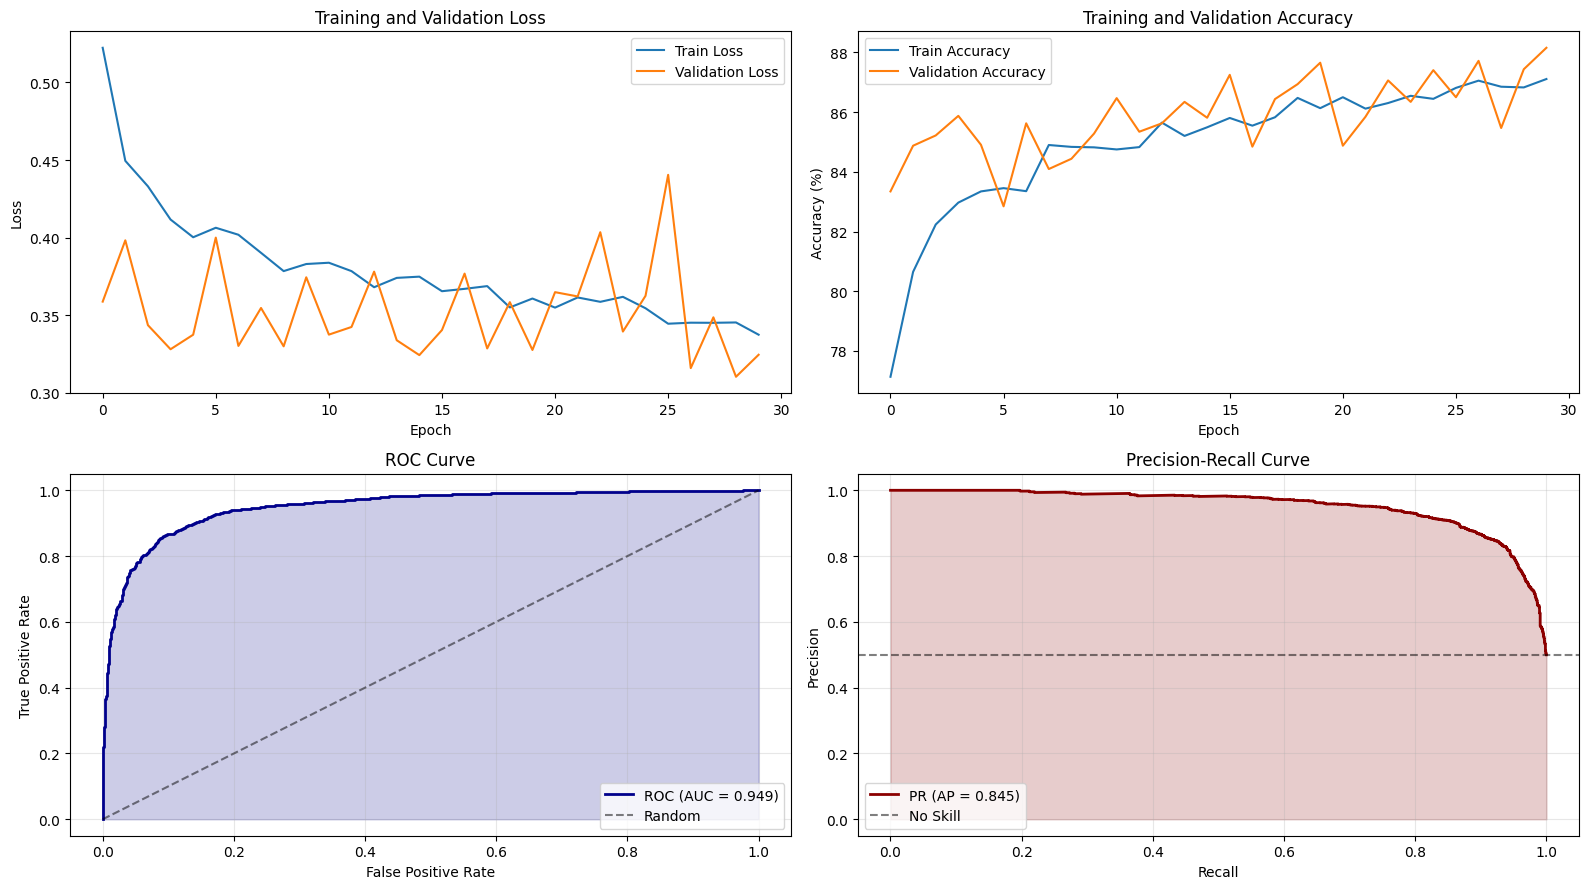

In [ ]:
### 4. neurons_nums=increased, hidden_size=increased ###

conv_layers = nn.Sequential(
    # First convolutional block
    nn.Conv1d(4, 64, kernel_size=12, padding=6),
    nn.ReLU(),
    nn.BatchNorm1d(64),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Second convolutional block
    nn.Conv1d(64, 256, kernel_size=10, padding=5),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Third convolutional block
    nn.Conv1d(256, 1024, kernel_size=8, padding=4),
    nn.ReLU(),
    nn.BatchNorm1d(1024),
    nn.MaxPool1d(2),
    nn.Dropout(0.3)
)

lstm_layer = nn.LSTM(
    input_size=1024,
    hidden_size=256,
    num_layers=1,
    batch_first=True,
    bidirectional=True
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(64, 4)
)

make_experiment(
    list(promoters.sequence.values), list(non_promoters.sequence.values),
    conv_layers, classifier, lstm_layer, model_type='CNN_RNN'
)

### 4-layer CNN

Using device: cuda
Training samples: 12800
Validation samples: 3200
Test samples: 4000
Starting training...
Epoch [10/30]
Train Loss: 0.3686, Train Acc: 84.91%
Val Loss: 0.3545, Val Acc: 85.81%
--------------------------------------------------
Epoch [20/30]
Train Loss: 0.3363, Train Acc: 86.44%
Val Loss: 0.3483, Val Acc: 84.34%
--------------------------------------------------
Epoch [30/30]
Train Loss: 0.3095, Train Acc: 87.86%
Val Loss: 0.3314, Val Acc: 87.00%
--------------------------------------------------
Test Accuracy: 87.47%

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      2000
           1       0.91      0.83      0.87      2000

    accuracy                           0.87      4000
   macro avg       0.88      0.87      0.87      4000
weighted avg       0.88      0.87      0.87      4000



<Figure size 1200x400 with 0 Axes>

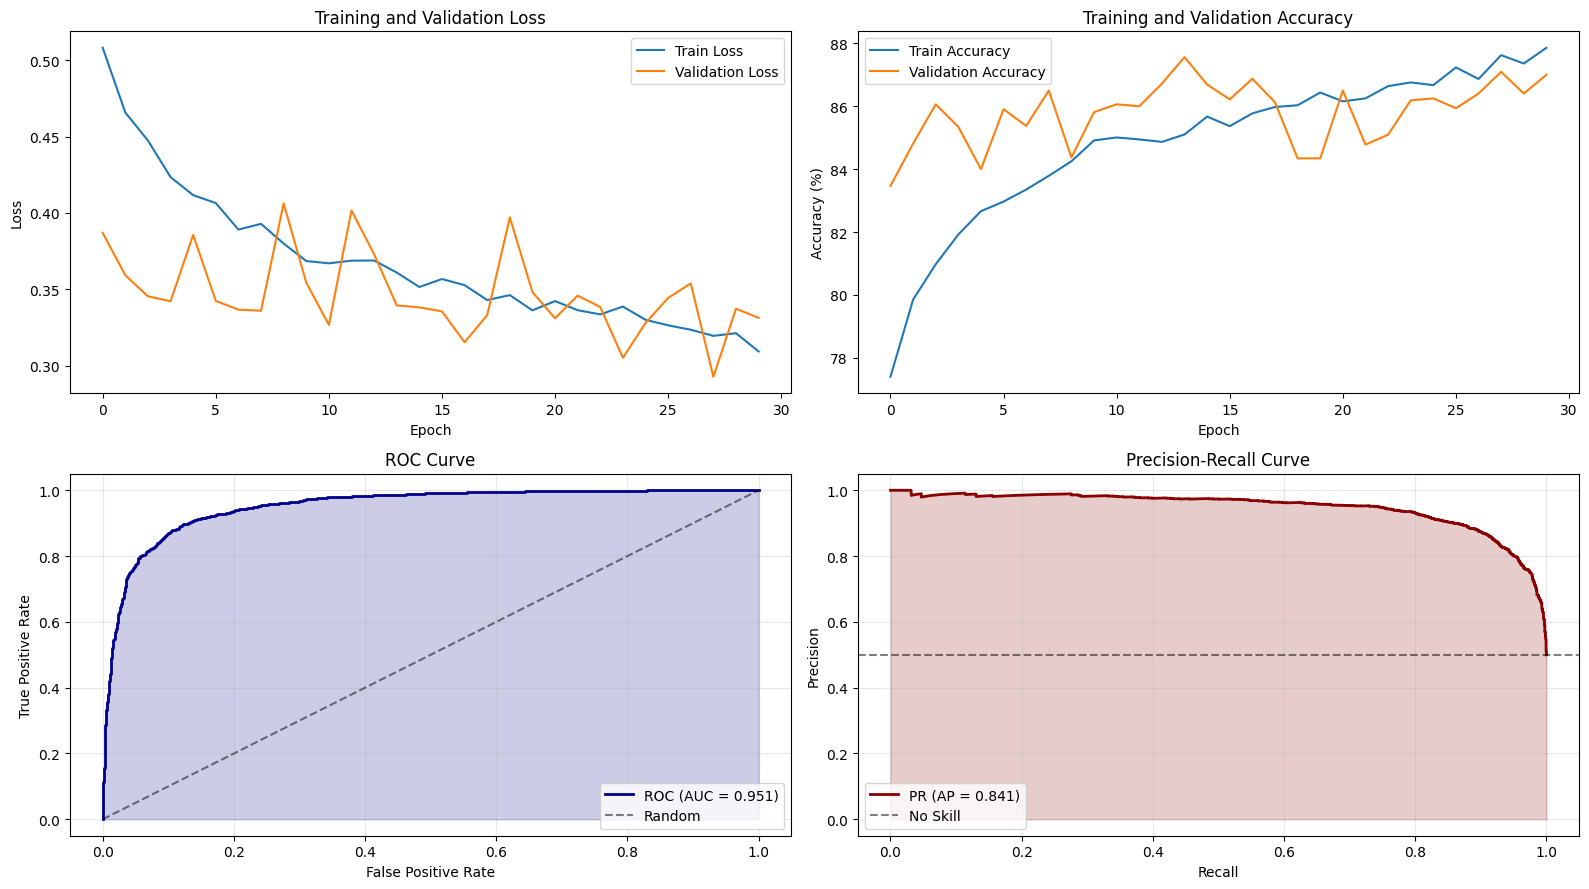

In [ ]:
### 1. neurons_nums=initial, hidden_size=initial ###

make_experiment(list(promoters.sequence.values), list(non_promoters.sequence.values), model_type='CNN_RNN')

Using device: cuda
Training samples: 12800
Validation samples: 3200
Test samples: 4000
Starting training...
Epoch [10/30]
Train Loss: 0.4102, Train Acc: 82.99%
Val Loss: 0.3486, Val Acc: 86.53%
--------------------------------------------------
Epoch [20/30]
Train Loss: 0.3717, Train Acc: 85.45%
Val Loss: 0.3195, Val Acc: 87.00%
--------------------------------------------------
Epoch [30/30]
Train Loss: 0.3566, Train Acc: 85.70%
Val Loss: 0.3112, Val Acc: 87.31%
--------------------------------------------------
Test Accuracy: 88.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.85      0.88      2000
           1       0.86      0.92      0.89      2000

    accuracy                           0.89      4000
   macro avg       0.89      0.89      0.88      4000
weighted avg       0.89      0.89      0.88      4000



<Figure size 1200x400 with 0 Axes>

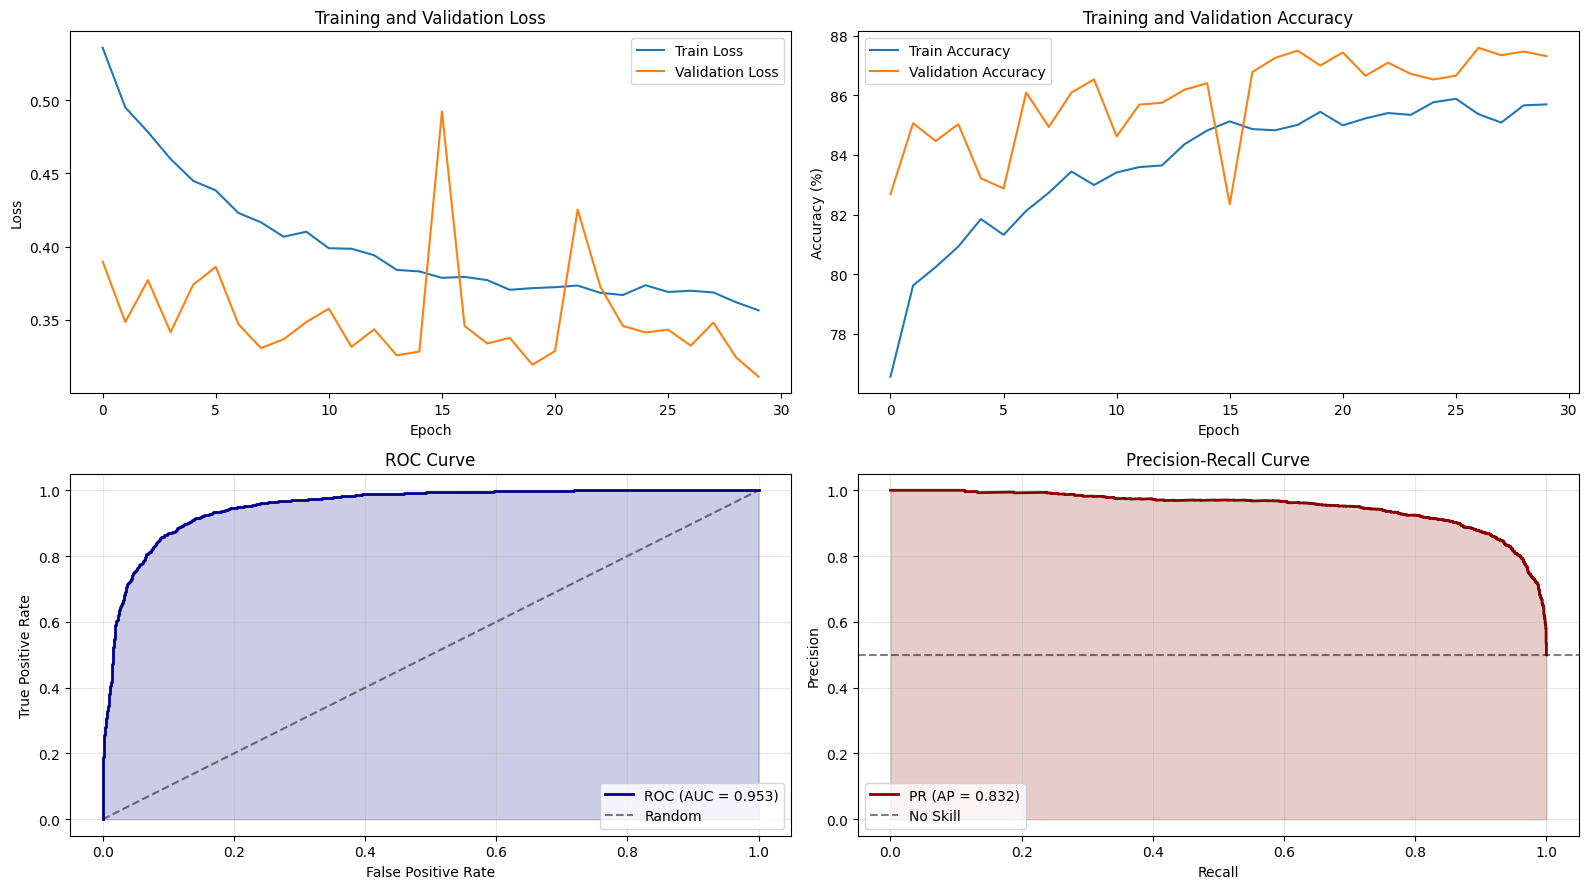

In [ ]:
### 2. neurons_nums=initial, hidden_size=increased ###

lstm_layer = nn.LSTM(
    input_size=512,
    hidden_size=256,
    num_layers=1,
    batch_first=True,
    bidirectional=True
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(64, 4)
)

make_experiment(
    list(promoters.sequence.values), list(non_promoters.sequence.values),
    classifier=classifier, lstm_layer=lstm_layer, model_type='CNN_RNN'
)

Using device: cuda
Training samples: 12800
Validation samples: 3200
Test samples: 4000
Starting training...
Epoch [10/30]
Train Loss: 0.3964, Train Acc: 83.05%
Val Loss: 0.3789, Val Acc: 84.56%
--------------------------------------------------
Epoch [20/30]
Train Loss: 0.3816, Train Acc: 83.84%
Val Loss: 0.3651, Val Acc: 86.28%
--------------------------------------------------
Epoch [30/30]
Train Loss: 0.3702, Train Acc: 84.67%
Val Loss: 0.3517, Val Acc: 84.88%
--------------------------------------------------
Test Accuracy: 85.95%

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.93      0.87      2000
           1       0.92      0.79      0.85      2000

    accuracy                           0.86      4000
   macro avg       0.87      0.86      0.86      4000
weighted avg       0.87      0.86      0.86      4000



<Figure size 1200x400 with 0 Axes>

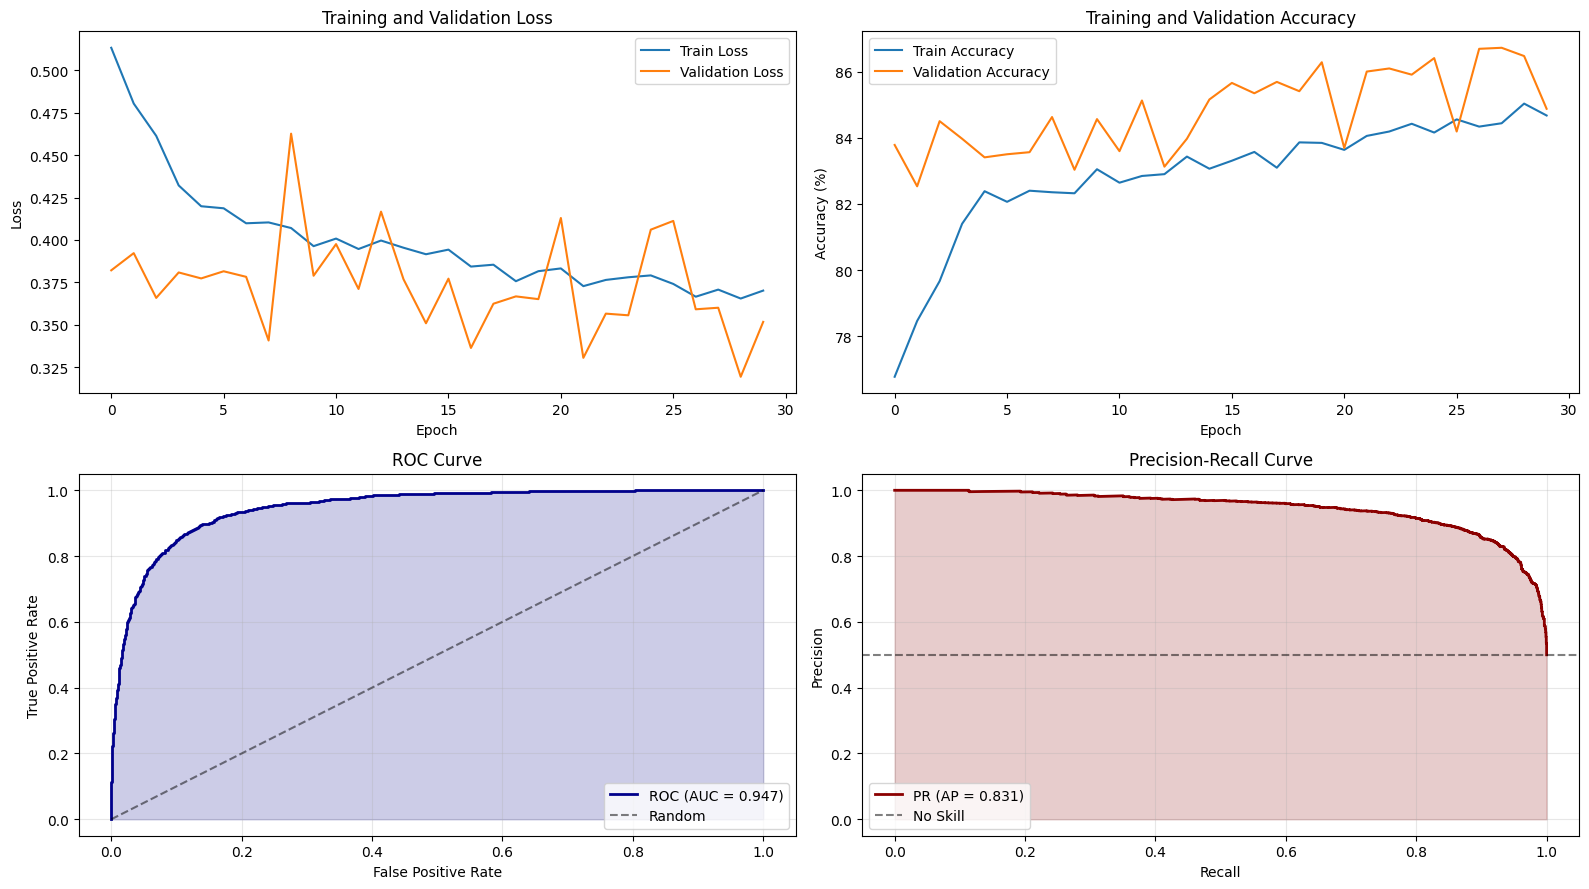

In [ ]:
### 3. neurons_nums=increased, hidden_size=initial ###

conv_layers = nn.Sequential(
    # First convolutional block
    nn.Conv1d(4, 32, kernel_size=10, padding=5),
    nn.ReLU(),
    nn.BatchNorm1d(32),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Second convolutional block
    nn.Conv1d(32, 128, kernel_size=8, padding=4),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Third convolutional block
    nn.Conv1d(128, 512, kernel_size=6, padding=3),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Fourth convolutional block
    nn.Conv1d(512, 1024, kernel_size=4, padding=2),
    nn.ReLU(),
    nn.BatchNorm1d(1024),
    nn.MaxPool1d(2),
    nn.Dropout(0.3)
)

lstm_layer = nn.LSTM(
    input_size=1024,
    hidden_size=128,
    num_layers=1,
    batch_first=True,
    bidirectional=True
)

make_experiment(
    list(promoters.sequence.values), list(non_promoters.sequence.values),
    conv_layers, lstm_layer=lstm_layer, model_type='CNN_RNN'
)

Using device: cuda
Training samples: 12800
Validation samples: 3200
Test samples: 4000
Starting training...
Epoch [10/30]
Train Loss: 0.4300, Train Acc: 81.24%
Val Loss: 0.3854, Val Acc: 84.62%
--------------------------------------------------
Epoch [20/30]
Train Loss: 0.4197, Train Acc: 82.10%
Val Loss: 0.4085, Val Acc: 85.06%
--------------------------------------------------
Epoch [30/30]
Train Loss: 0.3979, Train Acc: 83.28%
Val Loss: 0.3729, Val Acc: 86.03%
--------------------------------------------------
Test Accuracy: 86.55%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      2000
           1       0.85      0.89      0.87      2000

    accuracy                           0.87      4000
   macro avg       0.87      0.87      0.87      4000
weighted avg       0.87      0.87      0.87      4000



<Figure size 1200x400 with 0 Axes>

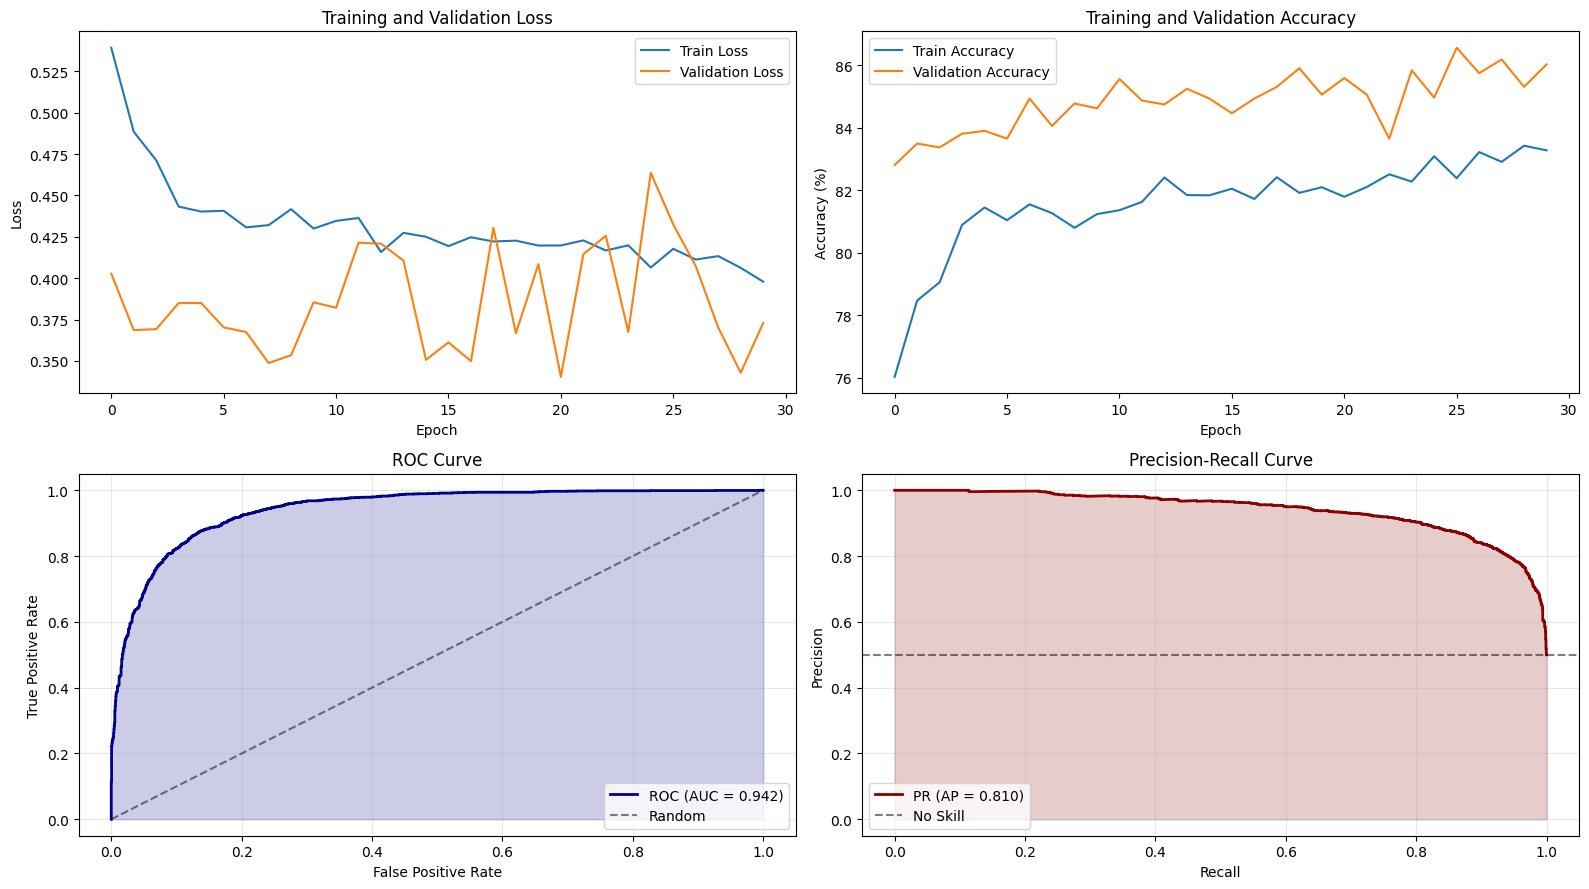

In [ ]:
### 4. neurons_nums=increased, hidden_size=increased ###

conv_layers = nn.Sequential(
    # First convolutional block
    nn.Conv1d(4, 32, kernel_size=10, padding=5),
    nn.ReLU(),
    nn.BatchNorm1d(32),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Second convolutional block
    nn.Conv1d(32, 128, kernel_size=8, padding=4),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Third convolutional block
    nn.Conv1d(128, 512, kernel_size=6, padding=3),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.MaxPool1d(2),
    nn.Dropout(0.3),

    # Fourth convolutional block
    nn.Conv1d(512, 1024, kernel_size=4, padding=2),
    nn.ReLU(),
    nn.BatchNorm1d(1024),
    nn.MaxPool1d(2),
    nn.Dropout(0.3)
)

lstm_layer = nn.LSTM(
    input_size=1024,
    hidden_size=256,
    num_layers=1,
    batch_first=True,
    bidirectional=True
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(64, 4)
)

make_experiment(
    list(promoters.sequence.values), list(non_promoters.sequence.values),
    conv_layers, classifier, lstm_layer, model_type='CNN_RNN'
)

## 6. LLM: HyenaDNA

### 6.1. HyenaDNA + Fine-tuning

In [3]:
class HyenaDNADataset(Dataset):
    def __init__(self, sequences, labels, max_length, model_name):
        self.sequences = sequences
        self.labels = labels
        self.max_length = max_length

        self.tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        tokens = self.tokenizer(
            self.sequences[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        input_ids = tokens['input_ids'].squeeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)

        return input_ids, label

In [ ]:
dataset = pd.read_csv('drive/MyDrive/CompLing/ADL/project/dataset.csv', header=0)

sequences = dataset.sequence.values
labels = dataset.label.values

train_seqs, test_seqs, train_labels, test_labels = train_test_split(
    sequences, labels, test_size=0.1, random_state=42, stratify=labels
)

max_length = 201
model_name = 'LongSafari/hyenadna-tiny-1k-seqlen-hf'

train_dataset = HyenaDNADataset(train_seqs, train_labels, max_length, model_name)
test_dataset = HyenaDNADataset(test_seqs, test_labels, max_length, model_name)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')

model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=2, trust_remote_code=True
).to(device)

# Backbone freezing:
for param in model.parameters():
    param.requires_grad = False

# Unfreezing final classification head:
for param in model.score.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(model.score.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

Устройство: cuda


modeling_hyena.py:   0%|          | 0.00/22.6k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/LongSafari/hyenadna-tiny-1k-seqlen-hf:
- modeling_hyena.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/1.81M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] HyenaDNAForSequenceClassification LOAD REPORT from: LongSafari/hyenadna-tiny-1k-seqlen-hf
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
epochs = 30
history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(epochs):
    # Обучение:
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for input_ids, labels in train_loader:
        input_ids, labels = input_ids.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids)
        logits = outputs.logits

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * input_ids.size(0)
        preds = torch.argmax(logits, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total

    # Валидация:
    model.eval()
    test_loss, test_correct, test_total = 0, 0, 0

    with torch.no_grad():
        for input_ids, labels in test_loader:
            input_ids, labels = input_ids.to(device), labels.to(device)
            outputs = model(input_ids=input_ids)
            logits = outputs.logits

            loss = criterion(logits, labels)
            test_loss += loss.item() * input_ids.size(0)
            preds = torch.argmax(logits, dim=1)
            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)

    epoch_test_loss = test_loss / test_total
    epoch_test_acc = test_correct / test_total

    history['train_loss'].append(epoch_train_loss)
    history['test_loss'].append(epoch_test_loss)
    history['train_acc'].append(epoch_train_acc)
    history['test_acc'].append(epoch_test_acc)

    print(
        f'Epoch {epoch + 1} | '
        f'Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | '
        f'Test Loss: {epoch_test_loss:.4f} Acc: {epoch_test_acc:.4f}'
    )

Epoch 1 | Train Loss: 0.3740 Acc: 0.8351 | Test Loss: 0.3664 Acc: 0.8340
Epoch 2 | Train Loss: 0.3736 Acc: 0.8351 | Test Loss: 0.3663 Acc: 0.8380
Epoch 3 | Train Loss: 0.3741 Acc: 0.8352 | Test Loss: 0.3585 Acc: 0.8360
Epoch 4 | Train Loss: 0.3737 Acc: 0.8331 | Test Loss: 0.3571 Acc: 0.8380
Epoch 5 | Train Loss: 0.3730 Acc: 0.8348 | Test Loss: 0.3608 Acc: 0.8370
Epoch 6 | Train Loss: 0.3732 Acc: 0.8337 | Test Loss: 0.3567 Acc: 0.8365
Epoch 7 | Train Loss: 0.3735 Acc: 0.8353 | Test Loss: 0.3702 Acc: 0.8320
Epoch 8 | Train Loss: 0.3738 Acc: 0.8339 | Test Loss: 0.3584 Acc: 0.8395
Epoch 9 | Train Loss: 0.3732 Acc: 0.8338 | Test Loss: 0.3648 Acc: 0.8350
Epoch 10 | Train Loss: 0.3737 Acc: 0.8328 | Test Loss: 0.3577 Acc: 0.8375
Epoch 11 | Train Loss: 0.3733 Acc: 0.8346 | Test Loss: 0.3572 Acc: 0.8380
Epoch 12 | Train Loss: 0.3729 Acc: 0.8340 | Test Loss: 0.3585 Acc: 0.8400
Epoch 13 | Train Loss: 0.3730 Acc: 0.8348 | Test Loss: 0.3616 Acc: 0.8360
Epoch 14 | Train Loss: 0.3729 Acc: 0.8351 | Tes

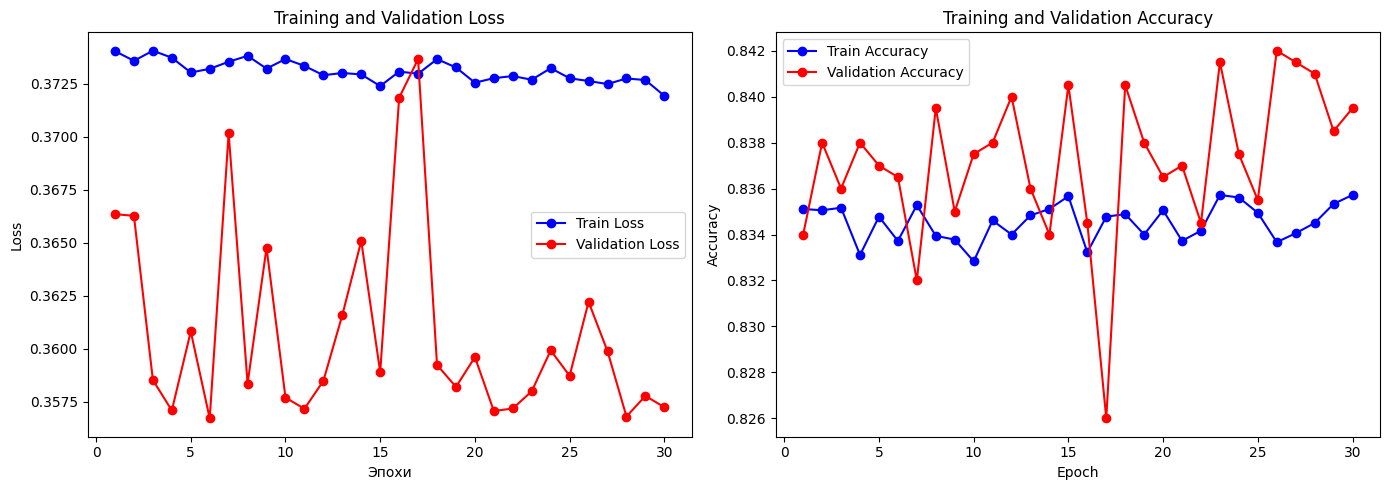

In [13]:
epochs_range = range(1, epochs + 1)
plt.figure(figsize=(14, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss')
plt.plot(epochs_range, history['test_loss'], 'r-o', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], 'b-o', label='Train Accuracy')
plt.plot(epochs_range, history['test_acc'], 'r-o', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## HyenaDNA + LoRA

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')

base_model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=2, trust_remote_code=True
).to(device)

peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules='all-linear',
    bias'none',
    modules_to_save=['score']
)

model = get_peft_model(base_model, peft_config).to(device)
model.print_trainable_parameters()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

Устройство: cuda


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] HyenaDNAForSequenceClassification LOAD REPORT from: LongSafari/hyenadna-tiny-1k-seqlen-hf
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 41,296 || all params: 477,648 || trainable%: 8.6457


In [23]:
epochs = 30
history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(epochs):
    # Обучение:
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for input_ids, labels in train_loader:
        input_ids, labels = input_ids.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids)
        logits = outputs.logits

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * input_ids.size(0)
        preds = torch.argmax(logits, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total

    # Валидация:
    model.eval()
    test_loss, test_correct, test_total = 0, 0, 0

    with torch.no_grad():
        for input_ids, labels in test_loader:
            input_ids, labels = input_ids.to(device), labels.to(device)
            outputs = model(input_ids=input_ids)
            logits = outputs.logits

            loss = criterion(logits, labels)
            test_loss += loss.item() * input_ids.size(0)
            preds = torch.argmax(logits, dim=1)
            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)

    epoch_test_loss = test_loss / test_total
    epoch_test_acc = test_correct / test_total

    history['train_loss'].append(epoch_train_loss)
    history['test_loss'].append(epoch_test_loss)
    history['train_acc'].append(epoch_train_acc)
    history['test_acc'].append(epoch_test_acc)

    print(
        f'Epoch {epoch + 1} | '
        f'Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | '
        f'Test Loss: {epoch_test_loss:.4f} Acc: {epoch_test_acc:.4f}'
    )

Epoch 1 | Train Loss: 0.3012 Acc: 0.8688 | Test Loss: 0.2638 Acc: 0.8695
Epoch 2 | Train Loss: 0.2625 Acc: 0.8886 | Test Loss: 0.2353 Acc: 0.8950
Epoch 3 | Train Loss: 0.2536 Acc: 0.8961 | Test Loss: 0.2356 Acc: 0.8980
Epoch 4 | Train Loss: 0.2409 Acc: 0.9013 | Test Loss: 0.2147 Acc: 0.9115
Epoch 5 | Train Loss: 0.2363 Acc: 0.9014 | Test Loss: 0.2465 Acc: 0.8970
Epoch 6 | Train Loss: 0.2315 Acc: 0.9037 | Test Loss: 0.2117 Acc: 0.9100
Epoch 7 | Train Loss: 0.2292 Acc: 0.9079 | Test Loss: 0.2289 Acc: 0.9025
Epoch 8 | Train Loss: 0.2330 Acc: 0.9054 | Test Loss: 0.2230 Acc: 0.9065
Epoch 9 | Train Loss: 0.2160 Acc: 0.9134 | Test Loss: 0.2057 Acc: 0.9115
Epoch 10 | Train Loss: 0.2167 Acc: 0.9131 | Test Loss: 0.2151 Acc: 0.9150
Epoch 11 | Train Loss: 0.2136 Acc: 0.9147 | Test Loss: 0.2182 Acc: 0.9065
Epoch 12 | Train Loss: 0.2077 Acc: 0.9170 | Test Loss: 0.2048 Acc: 0.9210
Epoch 13 | Train Loss: 0.2071 Acc: 0.9172 | Test Loss: 0.1962 Acc: 0.9180
Epoch 14 | Train Loss: 0.2261 Acc: 0.9077 | Tes

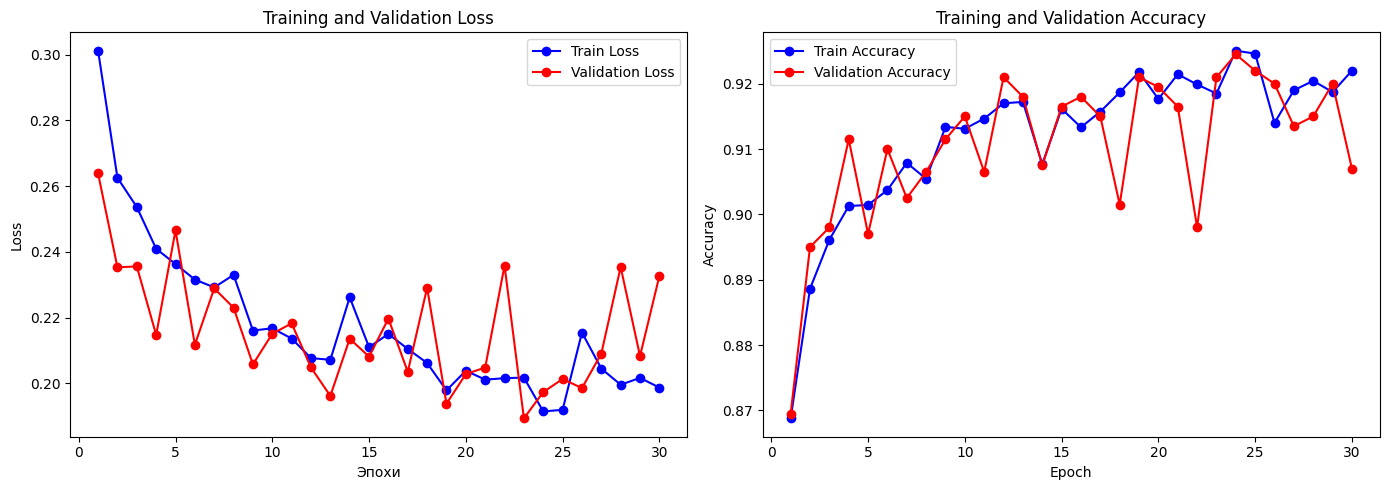

In [24]:
epochs_range = range(1, epochs + 1)
plt.figure(figsize=(14, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss')
plt.plot(epochs_range, history['test_loss'], 'r-o', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], 'b-o', label='Train Accuracy')
plt.plot(epochs_range, history['test_acc'], 'r-o', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()